# Moving-Average Crossover Backtest

## Project Objective

This project evaluates whether a 20-day and 50-day simple moving-average
crossover strategy can improve risk-adjusted performance relative to a
buy-and-hold benchmark.

The strategy is tested independently on:

- Apple (`AAPL`)
- Microsoft (`MSFT`)
- NVIDIA (`NVDA`)

The analysis compares the strategy and buy-and-hold using historical return,
annualized volatility, Sharpe ratio, maximum drawdown, market exposure, and
transaction costs.

## Research Hypothesis

When the 20-day simple moving average is above the 50-day simple moving average,
the asset is assumed to be in an upward-trending regime.

The strategy therefore holds the asset when:

\[
SMA_{20} > SMA_{50}
\]

and remains in cash when:

\[
SMA_{20} \leq SMA_{50}
\]

The research hypothesis is that this trend-following rule may reduce downside
risk and improve risk-adjusted performance compared with continuously holding
the asset.

In [1]:
# =========================================================
# PART 2 IMPORTS AND CONFIGURATION
# =========================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Path.cwd() now points to the project folder
PROJECT_FOLDER = Path.cwd()
DATA_FOLDER = PROJECT_FOLDER / "data"

FILES = {
    "AAPL": DATA_FOLDER / "aapl_us_d.csv",
    "MSFT": DATA_FOLDER / "msft_us_d.csv",
    "NVDA": DATA_FOLDER / "nvda_us_d.csv",
}

START_DATE = "2016-01-01"
END_DATE = "2025-12-31"

SHORT_WINDOW = 20
LONG_WINDOW = 50
VOLATILITY_WINDOW = 20

TRADING_DAYS = 252
RISK_FREE_RATE = 0.04
TRANSACTION_COST_RATE = 0.001
EXTREME_RETURN_THRESHOLD = 0.40


print("Project folder:", PROJECT_FOLDER)
print("Data folder:", DATA_FOLDER)

missing_files = []

for ticker, file_path in FILES.items():
    if file_path.is_file():
        print(f"{ticker}: FOUND — {file_path.name}")
    else:
        print(f"{ticker}: NOT FOUND — {file_path}")
        missing_files.append(file_path)

if missing_files:
    missing_text = "\n".join(str(path) for path in missing_files)

    raise FileNotFoundError(
        "The following data files could not be found:\n"
        f"{missing_text}"
    )

Project folder: C:\Users\darre\moving-average backtest quant project
Data folder: C:\Users\darre\moving-average backtest quant project\data
AAPL: FOUND — aapl_us_d.csv
MSFT: FOUND — msft_us_d.csv
NVDA: FOUND — nvda_us_d.csv


In [2]:
# =========================================================
# PROJECT PATHS
# =========================================================

# The notebook should be opened from the repository root folder
PROJECT_ROOT = Path.cwd()

DATA_DIRECTORY = PROJECT_ROOT / "data"
FIGURE_DIRECTORY = PROJECT_ROOT / "figures"


# Confirm that the data folder exists
if not DATA_DIRECTORY.is_dir():
    raise FileNotFoundError(
        "The data folder was not found. "
        "Open Jupyter Notebook from the repository root folder."
    )


# Create the figures folder if it does not already exist
FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)


# Define relative paths for the three CSV files
DATA_FILES = {
    "AAPL": DATA_DIRECTORY / "aapl_us_d.csv",
    "MSFT": DATA_DIRECTORY / "msft_us_d.csv",
    "NVDA": DATA_DIRECTORY / "nvda_us_d.csv"
}


# Confirm that every CSV file exists
missing_files = [
    str(file_path)
    for file_path in DATA_FILES.values()
    if not file_path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "The following data files were not found:\n"
        + "\n".join(missing_files)
    )


print("All project folders and data files validated successfully.")

All project folders and data files validated successfully.


## Part 3: Data Source

Daily historical price data were downloaded from Stooq in CSV format.

The dataset contains the following fields:

- `Date`
- `Open`
- `High`
- `Low`
- `Close`
- `Volume`

The analysis covers AAPL, MSFT, and NVDA over the common available period
between January 2016 and December 2025.

The same date range is used for all three assets so that their results can be
compared consistently. Dates unavailable for one or more assets are removed
when constructing aligned multi-asset datasets.

The backtest uses Stooq closing prices. The price series are checked for obvious
unadjusted stock-split discontinuities before returns and trading indicators
are calculated.

## Part 4: Data Loading and Cleaning

This section imports the three Stooq CSV files, standardizes their column names,
converts dates and numeric fields, removes invalid observations, sorts the data
chronologically, and restricts all assets to a common research period.

In [3]:
from pathlib import Path

import pandas as pd


# =========================================================
# PART 4: LOAD AND CLEAN HISTORICAL DATA
# =========================================================



DATA_FOLDER = Path("data")

FILES = {
    "AAPL": DATA_FOLDER / "aapl_us_d.csv",
    "MSFT": DATA_FOLDER / "msft_us_d.csv",
    "NVDA": DATA_FOLDER / "nvda_us_d.csv",
}


# Research period
# Change these dates when necessary.
START_DATE = "2016-01-01"
END_DATE = "2025-12-31"


def load_and_clean_stooq_data(
    file_path,
    ticker,
    start_date=None,
    end_date=None
):
    """
    Load and clean one daily Stooq CSV file.

    Expected columns:
    Date, Open, High, Low, Close, Volume
    """

    # -----------------------------------------------------
    # 1. Confirm that the file exists
    # -----------------------------------------------------

    if not file_path.exists():
        raise FileNotFoundError(
            f"{ticker} file was not found:\n"
            f"{file_path.resolve()}"
        )

    # -----------------------------------------------------
    # 2. Read the CSV file
    # -----------------------------------------------------

    df = pd.read_csv(file_path)

    # Remove unnecessary spaces from column names
    df.columns = [
        column.strip()
        for column in df.columns
    ]

    # Standardize column capitalization
    column_mapping = {
        "date": "Date",
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "volume": "Volume"
    }

    df = df.rename(
        columns={
            column: column_mapping.get(
                column.lower(),
                column
            )
            for column in df.columns
        }
    )

    # -----------------------------------------------------
    # 3. Check required columns
    # -----------------------------------------------------

    required_columns = [
        "Date",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{ticker} is missing these columns: "
            f"{missing_columns}"
        )

    # Keep only the columns needed for this project
    df = df[required_columns].copy()

    # -----------------------------------------------------
    # 4. Convert dates
    # -----------------------------------------------------

    df["Date"] = pd.to_datetime(
        df["Date"],
        errors="coerce"
    )

    # Remove rows with invalid dates
    df = df.dropna(subset=["Date"])

    # -----------------------------------------------------
    # 5. Convert price and volume data to numbers
    # -----------------------------------------------------

    numeric_columns = [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]

    for column in numeric_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

    # Remove rows with missing OHLC prices
    df = df.dropna(
        subset=[
            "Open",
            "High",
            "Low",
            "Close"
        ]
    )

    # -----------------------------------------------------
    # 6. Remove invalid observations
    # -----------------------------------------------------

    price_columns = [
        "Open",
        "High",
        "Low",
        "Close"
    ]

    # All prices must be greater than zero
    valid_price_rows = (
        df[price_columns] > 0
    ).all(axis=1)

    df = df.loc[valid_price_rows].copy()

    # Volume cannot be negative
    df = df.loc[
        df["Volume"].isna()
        | (df["Volume"] >= 0)
    ].copy()

    # -----------------------------------------------------
    # 7. Remove duplicate dates
    # -----------------------------------------------------

    df = df.drop_duplicates(
        subset="Date",
        keep="first"
    )

    # -----------------------------------------------------
    # 8. Sort chronologically
    # -----------------------------------------------------

    # Stooq may provide newest dates first.
    df = df.sort_values("Date")

    # Set Date as the index
    df = df.set_index("Date")

    # -----------------------------------------------------
    # 9. Filter the research period
    # -----------------------------------------------------

    if start_date is not None:
        df = df.loc[
            df.index >= pd.Timestamp(start_date)
        ]

    if end_date is not None:
        df = df.loc[
            df.index <= pd.Timestamp(end_date)
        ]

    # -----------------------------------------------------
    # 10. Add ticker identification
    # -----------------------------------------------------

    df["Ticker"] = ticker

    # Reorder the columns
    df = df[
        [
            "Ticker",
            "Open",
            "High",
            "Low",
            "Close",
            "Volume"
        ]
    ]

    if df.empty:
        raise ValueError(
            f"No usable {ticker} data remains after "
            f"cleaning and date filtering."
        )

    return df


# =========================================================
# LOAD ALL THREE ASSETS
# =========================================================

asset_data = {}

for ticker, file_path in FILES.items():

    asset_data[ticker] = load_and_clean_stooq_data(
        file_path=file_path,
        ticker=ticker,
        start_date=START_DATE,
        end_date=END_DATE
    )


# Create individual DataFrames
aapl = asset_data["AAPL"]
msft = asset_data["MSFT"]
nvda = asset_data["NVDA"]


# =========================================================
# DISPLAY DATASET INFORMATION
# =========================================================

for ticker, df in asset_data.items():

    print("=" * 70)
    print(ticker)
    print("=" * 70)

    print(f"Rows: {len(df):,}")
    print(f"First date: {df.index.min().date()}")
    print(f"Last date:  {df.index.max().date()}")

    print("\nFirst five rows:")
    print(df.head())

    print("\nLast five rows:")
    print(df.tail())

    print("\nSummary:")
    df.info()

    print("\nMissing values:")
    print(df.isna().sum())

    print("\nData types:")
    print(df.dtypes)

    print()


# =========================================================
# RESTRICT ALL THREE ASSETS TO A COMMON DATE RANGE
# =========================================================

common_start_date = max(
    df.index.min()
    for df in asset_data.values()
)

common_end_date = min(
    df.index.max()
    for df in asset_data.values()
)

print("=" * 70)
print("COMMON AVAILABLE PERIOD")
print("=" * 70)
print("Common start date:", common_start_date.date())
print("Common end date:  ", common_end_date.date())


for ticker in asset_data:

    asset_data[ticker] = asset_data[ticker].loc[
        common_start_date:common_end_date
    ].copy()


# Update the individual DataFrames after filtering
aapl = asset_data["AAPL"]
msft = asset_data["MSFT"]
nvda = asset_data["NVDA"]


# =========================================================
# CREATE AN ALIGNED CLOSING-PRICE DATAFRAME
# =========================================================

close_prices = pd.concat(
    {
        ticker: df["Close"]
        for ticker, df in asset_data.items()
    },
    axis=1
)

# Keep only dates available for all three assets
close_prices = close_prices.dropna()


print("\n" + "=" * 70)
print("ALIGNED CLOSING PRICES")
print("=" * 70)

print(close_prices.head())

print("\nDataset dimensions:")
print(close_prices.shape)

print("\nFinal aligned date range:")
print(
    close_prices.index.min().date(),
    "to",
    close_prices.index.max().date()
)

print("\nMissing values:")
print(close_prices.isna().sum())

AAPL
Rows: 2,514
First date: 2016-01-04
Last date:  2025-12-31

First five rows:
           Ticker     Open     High      Low    Close     Volume
Date                                                            
2016-01-04   AAPL  23.1136  23.7397  22.9793  23.7347  278921861
2016-01-05   AAPL  23.8201  23.8448  23.0697  23.1365  234060370
2016-01-06   AAPL  22.6524  23.0607  22.4958  22.6841  298533216
2016-01-07   AAPL  22.2287  22.5545  21.7224  21.7263  340144808
2016-01-08   AAPL  22.2002  22.3257  21.7959  21.8402  308853529

Last five rows:
           Ticker     Open     High      Low    Close    Volume
Date                                                           
2025-12-24   AAPL  272.085  275.173  271.941  273.554  17927333
2025-12-26   AAPL  273.904  275.113  272.605  273.144  21541940
2025-12-29   AAPL  272.435  274.104  272.095  273.504  23737403
2025-12-30   AAPL  272.555  273.824  272.025  272.825  22160333
2025-12-31   AAPL  272.805  273.424  271.496  271.606  27319178

### Data-Cleaning Result

The cleaned dataset contains 2,514 daily observations from January 4, 2016,
through December 31, 2025. All required OHLCV fields are complete, and no
missing values remain.

The date field is stored as a chronological `DatetimeIndex`. Price fields are
stored as floating-point values, volume is stored as an integer, and the ticker
identifier is stored as text. The dataset is therefore ready for return
calculation and feature engineering.

## Data Validation and Adjustment Check

### Data-Cleaning Validation

The cleaned AAPL, MSFT, and NVDA datasets each contain 2,514 daily observations
from January 4, 2016, through December 31, 2025.

All required OHLCV fields are complete, and no missing values remain. The date
field is stored as a chronological `DatetimeIndex`. Price fields are stored as
floating-point values, volume is stored as an integer, and the ticker identifier
is stored as text.

The datasets are therefore ready for return calculation, feature engineering,
and backtesting.

### Stock-Split Adjustment Check

A 40% absolute daily-return threshold was used as an initial screening rule for
unusually large price discontinuities.

This threshold would detect an unadjusted 2-for-1 stock split, which could create
an apparent return of approximately −50%, as well as larger stock splits that
would produce even larger artificial declines.

No daily closing-price changes of 40% or more were detected for AAPL, MSFT, or
NVDA. This suggests that the price series do not contain obvious unadjusted
stock-split discontinuities.

However, this screening rule is a diagnostic heuristic rather than definitive
proof that every corporate action has been fully adjusted.

In [4]:
# =========================================================
# EXTREME-RETURN DIAGNOSTIC
# =========================================================

EXTREME_RETURN_THRESHOLD = 0.40  # 40% absolute daily return


for ticker, df in asset_data.items():

    check_df = df.copy().sort_index()

    # Calculate daily closing-price returns
    check_df["Daily_Return"] = (
        check_df["Close"]
        .pct_change(fill_method=None)
    )

    # Identify returns whose absolute value is at least 40%
    extreme_returns = check_df.loc[
        check_df["Daily_Return"].abs()
        >= EXTREME_RETURN_THRESHOLD,
        [
            "Close",
            "Daily_Return"
        ]
    ].copy()

    print("=" * 70)
    print(f"{ticker} EXTREME-RETURN DIAGNOSTIC")
    print("=" * 70)

    if extreme_returns.empty:
        print(
            "No daily closing-price changes of "
            f"{EXTREME_RETURN_THRESHOLD:.0%} or more were detected."
        )

    else:
        print(
            f"{len(extreme_returns)} daily closing-price change(s) of "
            f"{EXTREME_RETURN_THRESHOLD:.0%} or more were detected."
        )

        display(
            extreme_returns.style.format({
                "Close": "{:.4f}",
                "Daily_Return": "{:.2%}"
            })
        )

    print()

AAPL EXTREME-RETURN DIAGNOSTIC
No daily closing-price changes of 40% or more were detected.

MSFT EXTREME-RETURN DIAGNOSTIC
No daily closing-price changes of 40% or more were detected.

NVDA EXTREME-RETURN DIAGNOSTIC
No daily closing-price changes of 40% or more were detected.



### Interpretation of the Extreme-Return Diagnostic

No daily closing-price changes of 40% or more were detected for AAPL, MSFT, or
NVDA during the sample period.

This indicates that the datasets do not contain obvious price discontinuities
consistent with unadjusted major stock splits. For example, an unadjusted
2-for-1 split could produce an apparent one-day return of approximately −50%,
while larger splits could create even larger artificial declines.

The result therefore supports the use of the Stooq closing-price series for
daily-return calculation and backtesting.

However, the 40% threshold is only a screening heuristic. It does not prove that
all corporate actions are fully adjusted, and it does not confirm whether
dividends are included. Dividend treatment is evaluated separately.

### Dividend Treatment

The original Stooq CSV files were inspected for separate dividend fields and
explicit dividend-event rows. No separate dividend column or dividend-event
records were found in the downloaded files.

The backtest therefore uses closing-price returns and should be interpreted as
a price-return analysis rather than a confirmed total-return analysis.

## Part 5: Feature Engineering

After loading, cleaning, and validating the historical data, the next step is to
construct the variables used by the trading strategy.

For each asset, this section calculates:

- Daily closing-price returns
- The 20-day simple moving average (`SMA20`)
- The 50-day simple moving average (`SMA50`)
- The 20-day rolling volatility
- The annualized 20-day rolling volatility

The moving averages will later be used to generate the SMA20/SMA50 crossover
signal. Rolling volatility is included to describe how each asset's risk changes
through time.

Missing values at the beginning of these feature columns are expected because
rolling calculations require a minimum number of prior observations.

In [5]:
import numpy as np
import pandas as pd


# =========================================================
# PART 5: CREATE FEATURES FOR THREE ASSETS
# =========================================================

SHORT_WINDOW = 20
LONG_WINDOW = 50
VOLATILITY_WINDOW = 20
TRADING_DAYS = 252


def create_features(
    df,
    short_window=20,
    long_window=50,
    volatility_window=20,
    trading_days=252
):
    """
    Create quantitative features for one asset.

    Features:
    - Daily simple return
    - SMA20
    - SMA50
    - 20-day rolling volatility
    - Annualized 20-day rolling volatility

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned OHLCV data from Part 4.

    short_window : int
        Window for the short moving average.

    long_window : int
        Window for the long moving average.

    volatility_window : int
        Window for rolling volatility.

    trading_days : int
        Number of trading days used for annualization.

    Returns
    -------
    pd.DataFrame
        Original data with additional feature columns.
    """

    # Work with a copy so the original DataFrame is not modified
    df = df.copy()

    # -----------------------------------------------------
    # 1. Validate the data
    # -----------------------------------------------------

    if "Close" not in df.columns:
        raise ValueError(
            "The DataFrame must contain a 'Close' column."
        )

    if short_window <= 0:
        raise ValueError(
            "short_window must be greater than zero."
        )

    if long_window <= short_window:
        raise ValueError(
            "long_window must be greater than short_window."
        )

    if volatility_window <= 1:
        raise ValueError(
            "volatility_window must be greater than one."
        )

    # Ensure dates are in chronological order
    df = df.sort_index()

    # -----------------------------------------------------
    # 2. Daily return
    # -----------------------------------------------------

    df["Return"] = df["Close"].pct_change(
        fill_method=None
    )

    # -----------------------------------------------------
    # 3. Short simple moving average
    # -----------------------------------------------------

    short_column = f"SMA{short_window}"

    df[short_column] = (
        df["Close"]
        .rolling(
            window=short_window,
            min_periods=short_window
        )
        .mean()
    )

    # -----------------------------------------------------
    # 4. Long simple moving average
    # -----------------------------------------------------

    long_column = f"SMA{long_window}"

    df[long_column] = (
        df["Close"]
        .rolling(
            window=long_window,
            min_periods=long_window
        )
        .mean()
    )

    # -----------------------------------------------------
    # 5. Rolling daily volatility
    # -----------------------------------------------------

    volatility_column = (
        f"Volatility{volatility_window}"
    )

    df[volatility_column] = (
        df["Return"]
        .rolling(
            window=volatility_window,
            min_periods=volatility_window
        )
        .std(ddof=1)
    )

    # -----------------------------------------------------
    # 6. Annualized rolling volatility
    # -----------------------------------------------------

    annualized_volatility_column = (
        f"Annualized_Volatility{volatility_window}"
    )

    df[annualized_volatility_column] = (
        df[volatility_column]
        * np.sqrt(trading_days)
    )

    return df


# =========================================================
# APPLY FEATURE ENGINEERING TO ALL THREE ASSETS
# =========================================================

feature_data = {}

for ticker, df in asset_data.items():

    feature_data[ticker] = create_features(
        df=df,
        short_window=SHORT_WINDOW,
        long_window=LONG_WINDOW,
        volatility_window=VOLATILITY_WINDOW,
        trading_days=TRADING_DAYS
    )


# Individual DataFrames with features
aapl_features = feature_data["AAPL"]
msft_features = feature_data["MSFT"]
nvda_features = feature_data["NVDA"]


# =========================================================
# DISPLAY RESULTS FOR EACH ASSET
# =========================================================

feature_columns = [
    "Close",
    "Return",
    f"SMA{SHORT_WINDOW}",
    f"SMA{LONG_WINDOW}",
    f"Volatility{VOLATILITY_WINDOW}",
    f"Annualized_Volatility{VOLATILITY_WINDOW}"
]


for ticker, df in feature_data.items():

    print("=" * 80)
    print(f"{ticker} FEATURE DATA")
    print("=" * 80)

    print("\nFirst rows containing complete features:")

    complete_features = df[
        feature_columns
    ].dropna()

    print(complete_features.head())

    print("\nLast five rows:")

    print(
        df[feature_columns].tail()
    )

    print("\nMissing values:")

    print(
        df[feature_columns]
        .isna()
        .sum()
    )

    print()


# =========================================================
# CREATE ALIGNED DAILY RETURNS FOR THREE ASSETS
# =========================================================

daily_returns = pd.concat(
    {
        ticker: df["Return"]
        for ticker, df in feature_data.items()
    },
    axis=1
)

# Keep dates shared by all three assets
daily_returns = daily_returns.dropna()


print("=" * 80)
print("ALIGNED DAILY RETURNS")
print("=" * 80)

print(daily_returns.head())

print("\nDataset shape:")
print(daily_returns.shape)

print("\nDate range:")
print(
    daily_returns.index.min().date(),
    "to",
    daily_returns.index.max().date()
)


# =========================================================
# CREATE A BASIC FEATURE SUMMARY
# =========================================================

summary_rows = []

for ticker, df in feature_data.items():

    returns = df["Return"].dropna()

    summary_rows.append(
        {
            "Ticker": ticker,
            "Observations": len(returns),
            "Mean Daily Return": returns.mean(),
            "Daily Volatility": returns.std(ddof=1),
            "Annualized Return":
                returns.mean() * TRADING_DAYS,
            "Annualized Volatility":
                returns.std(ddof=1)
                * np.sqrt(TRADING_DAYS),
            "Maximum Daily Return": returns.max(),
            "Minimum Daily Return": returns.min()
        }
    )


feature_summary = (
    pd.DataFrame(summary_rows)
    .set_index("Ticker")
)


print("\n" + "=" * 80)
print("FEATURE SUMMARY")
print("=" * 80)

display(feature_summary)


# =========================================================
# OPTIONAL: DISPLAY EACH DATAFRAME
# =========================================================

display(aapl_features.tail())
display(msft_features.tail())
display(nvda_features.tail())

AAPL FEATURE DATA

First rows containing complete features:
              Close    Return      SMA20      SMA50  Volatility20  \
Date                                                                
2016-03-15  23.6886  0.020273  22.521575  22.166928      0.014004   
2016-03-16  23.9958  0.012968  22.610180  22.172150      0.013908   
2016-03-17  23.9577 -0.001588  22.718025  22.188574      0.012903   
2016-03-18  23.9861  0.001185  22.829740  22.214614      0.012827   
2016-03-21  23.9832 -0.000121  22.931895  22.259752      0.012844   

            Annualized_Volatility20  
Date                                 
2016-03-15                 0.222314  
2016-03-16                 0.220785  
2016-03-17                 0.204829  
2016-03-18                 0.203619  
2016-03-21                 0.203900  

Last five rows:
              Close    Return      SMA20      SMA50  Volatility20  \
Date                                                                
2025-12-24  273.554  0.005325  276.

,Observations,Mean Daily Return,Daily Volatility,Annualized Return,Annualized Volatility,Maximum Daily Return,Minimum Daily Return
Ticker,,,,,,,
AAPL,2513,0.001138,0.018298,0.286653,0.290479,0.153299,-0.128634
MSFT,2513,0.001059,0.016853,0.266811,0.267533,0.142218,-0.147472
NVDA,2513,0.002666,0.031431,0.671907,0.498955,0.298012,-0.187536


,Ticker,Open,High,Low,Close,Volume,Return,SMA20,SMA50,Volatility20,Annualized_Volatility20
Date,,,,,,,,,,,
2025-12-24,AAPL,272.085,275.173,271.941,273.554,17927333,0.005325,276.89285,270.70126,0.007906,0.125502
2025-12-26,AAPL,273.904,275.113,272.605,273.144,21541940,-0.001499,276.68550,271.18682,0.007884,0.125147
2025-12-29,AAPL,272.435,274.104,272.095,273.504,23737403,0.001318,276.43125,271.71732,0.007798,0.123783
2025-12-30,AAPL,272.555,273.824,272.025,272.825,22160333,-0.002483,275.93075,272.13762,0.006813,0.108146
2025-12-31,AAPL,272.805,273.424,271.496,271.606,27319178,-0.004468,275.21495,272.33492,0.006139,0.097457


,Ticker,Open,High,Low,Close,Volume,Return,SMA20,SMA50,Volatility20,Annualized_Volatility20
Date,,,,,,,,,,,
2025-12-24,MSFT,485.680,489.1625,484.83,488.02,5855880.0,0.002403,483.8300,498.6952,0.012425,0.197246
2025-12-26,MSFT,486.705,488.1200,485.96,487.71,8842175.0,-0.000635,483.9405,498.1808,0.011795,0.187243
2025-12-29,MSFT,484.855,488.3500,484.18,487.10,10893408.0,-0.001251,483.6950,497.6906,0.011386,0.180743
2025-12-30,MSFT,485.930,489.6800,485.50,487.48,13944512.0,0.000780,483.7320,497.1686,0.011127,0.176637
2025-12-31,MSFT,487.840,488.1400,483.30,483.62,15601554.0,-0.007918,483.4130,496.5052,0.011153,0.177054


,Ticker,Open,High,Low,Close,Volume,Return,SMA20,SMA50,Volatility20,Annualized_Volatility20
Date,,,,,,,,,,,
2025-12-24,NVDA,187.94,188.910,186.59,188.61,65528545,-0.003171,180.7930,185.8516,0.019875,0.315513
2025-12-26,NVDA,189.92,192.690,188.00,190.53,139740292,0.010180,181.3065,186.0656,0.019792,0.314184
2025-12-29,NVDA,187.71,188.755,185.91,188.22,120006103,-0.012124,181.8675,186.1938,0.019501,0.309567
2025-12-30,NVDA,188.24,188.990,186.93,187.54,97687274,-0.003613,182.2485,186.2802,0.019300,0.306375
2025-12-31,NVDA,189.57,190.560,186.49,186.50,120100484,-0.005545,182.5005,186.3574,0.019315,0.306615


### Feature Engineering Results

Daily returns, SMA20, SMA50, 20-day rolling volatility, and annualized 20-day
rolling volatility were successfully calculated for AAPL, MSFT, and NVDA.

The missing values at the beginning of the feature columns are expected:

- `Return` requires one previous closing price.
- `SMA20` requires 20 observations.
- `Volatility20` requires 20 daily returns.
- `SMA50` requires 50 observations.

These initial missing values do not indicate a data-quality problem. They result
from the minimum historical observations required for each rolling calculation.

The feature datasets are now ready for signal generation. In the next section,
the strategy will hold an asset when its SMA20 is above its SMA50 and remain in
cash otherwise.

## Part 6: Signal Generation

This section converts the moving-average features into a long-or-cash trading
signal for AAPL, MSFT, and NVDA.

The strategy applies the following rule:

- `Signal = 1` when `SMA20 > SMA50`
- `Signal = 0` when `SMA20 <= SMA50`

A signal value of `1` means that the strategy intends to hold the asset. A
signal value of `0` means that the strategy intends to remain in cash.

The signal is based on the current day's closing-price information. It represents
the desired position rather than the executable position.

In Part 7, the signal will be shifted forward by one trading day to create the
`Position` column and reduce look-ahead bias.

In [6]:
import pandas as pd


# =========================================================
# PART 6: SIGNAL GENERATION
# =========================================================

SHORT_WINDOW = 20
LONG_WINDOW = 50


def generate_signal(
    df,
    short_window=20,
    long_window=50
):
    """
    Generate a long-or-cash signal using an SMA crossover.

    Signal = 1:
        SMA20 is above SMA50.
        The strategy intends to hold the asset.

    Signal = 0:
        SMA20 is less than or equal to SMA50.
        The strategy intends to remain in cash.

    This function creates the desired signal only.
    The signal will be shifted by one trading day in Part 7.
    """

    df = df.copy()
    df = df.sort_index()

    short_column = f"SMA{short_window}"
    long_column = f"SMA{long_window}"

    # -----------------------------------------------------
    # 1. Validate required columns
    # -----------------------------------------------------

    required_columns = [
        "Close",
        short_column,
        long_column
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    if short_window <= 0:
        raise ValueError(
            "short_window must be greater than zero."
        )

    if long_window <= short_window:
        raise ValueError(
            "long_window must be greater than short_window."
        )

    # -----------------------------------------------------
    # 2. Generate the SMA crossover signal
    # -----------------------------------------------------

    df["Signal"] = 0

    valid_indicators = (
        df[short_column].notna()
        & df[long_column].notna()
    )

    df.loc[
        valid_indicators
        & (df[short_column] > df[long_column]),
        "Signal"
    ] = 1

    df["Signal"] = df["Signal"].astype(int)

    return df


# =========================================================
# APPLY SIGNAL GENERATION TO ALL THREE ASSETS
# =========================================================

signal_data = {}

for ticker, df in feature_data.items():

    signal_data[ticker] = generate_signal(
        df=df,
        short_window=SHORT_WINDOW,
        long_window=LONG_WINDOW
    )


# Individual DataFrames
aapl_signals = signal_data["AAPL"]
msft_signals = signal_data["MSFT"]
nvda_signals = signal_data["NVDA"]


# =========================================================
# DISPLAY THE MOST RECENT SIGNALS
# =========================================================

signal_columns = [
    "Close",
    f"SMA{SHORT_WINDOW}",
    f"SMA{LONG_WINDOW}",
    "Signal"
]


for ticker, df in signal_data.items():

    print("=" * 70)
    print(f"{ticker} SIGNAL DATA")
    print("=" * 70)

    valid_signal_data = df.dropna(
        subset=[
            f"SMA{SHORT_WINDOW}",
            f"SMA{LONG_WINDOW}"
        ]
    )

    display(
        valid_signal_data[
            signal_columns
        ].tail(10)
    )


# =========================================================
# CREATE SIGNAL SUMMARY
# =========================================================

summary_rows = []

for ticker, df in signal_data.items():

    valid_df = df.dropna(
        subset=[
            f"SMA{SHORT_WINDOW}",
            f"SMA{LONG_WINDOW}"
        ]
    )

    days_long = int(
        (valid_df["Signal"] == 1).sum()
    )

    days_in_cash = int(
        (valid_df["Signal"] == 0).sum()
    )

    total_valid_days = len(valid_df)

    percentage_long = (
        days_long / total_valid_days
        if total_valid_days > 0
        else float("nan")
    )

    latest_signal = (
        int(valid_df["Signal"].iloc[-1])
        if not valid_df.empty
        else None
    )

    summary_rows.append(
        {
            "Ticker": ticker,
            "Days Signal = 1": days_long,
            "Days Signal = 0": days_in_cash,
            "Percentage Signal = 1": percentage_long,
            "Latest Signal": latest_signal
        }
    )


signal_summary = (
    pd.DataFrame(summary_rows)
    .set_index("Ticker")
)


print("=" * 70)
print("SIGNAL SUMMARY")
print("=" * 70)

display(signal_summary)


# Optional formatted summary
formatted_signal_summary = signal_summary.copy()

formatted_signal_summary[
    "Percentage Signal = 1"
] = formatted_signal_summary[
    "Percentage Signal = 1"
].map(
    lambda value: (
        f"{value:.2%}"
        if pd.notna(value)
        else "N/A"
    )
)

display(formatted_signal_summary)

AAPL SIGNAL DATA


,Close,SMA20,SMA50,Signal
Date,,,,
2025-12-17,271.586,276.70250,268.47508,1
2025-12-18,271.936,276.88385,268.76242,1
2025-12-19,273.414,277.25450,269.15956,1
2025-12-22,270.717,277.22855,269.67784,1
2025-12-23,272.105,277.05070,270.17616,1
2025-12-24,273.554,276.89285,270.70126,1
2025-12-26,273.144,276.68550,271.18682,1
2025-12-29,273.504,276.43125,271.71732,1
2025-12-30,272.825,275.93075,272.13762,1


MSFT SIGNAL DATA


,Close,SMA20,SMA50,Signal
Date,,,,
2025-12-17,476.12,481.7785,501.8180,0
2025-12-18,483.98,481.6215,501.0006,0
2025-12-19,485.92,481.9960,500.2710,0
2025-12-22,484.92,482.6360,499.7502,0
2025-12-23,486.85,483.2785,499.2062,0
2025-12-24,488.02,483.8300,498.6952,0
2025-12-26,487.71,483.9405,498.1808,0
2025-12-29,487.10,483.6950,497.6906,0
2025-12-30,487.48,483.7320,497.1686,0


NVDA SIGNAL DATA


,Close,SMA20,SMA50,Signal
Date,,,,
2025-12-17,170.94,180.2815,186.1826,0
2025-12-18,174.14,179.6625,185.8832,0
2025-12-19,180.99,179.6800,185.6516,0
2025-12-22,183.69,179.9205,185.6622,0
2025-12-23,189.21,180.2535,185.6800,0
2025-12-24,188.61,180.7930,185.8516,0
2025-12-26,190.53,181.3065,186.0656,0
2025-12-29,188.22,181.8675,186.1938,0
2025-12-30,187.54,182.2485,186.2802,0


SIGNAL SUMMARY


,Days Signal = 1,Days Signal = 0,Percentage Signal = 1,Latest Signal
Ticker,,,,
AAPL,1628,837,0.660446,1
MSFT,1770,695,0.718053,0
NVDA,1740,725,0.705882,0


,Days Signal = 1,Days Signal = 0,Percentage Signal = 1,Latest Signal
Ticker,,,,
AAPL,1628,837,66.04%,1
MSFT,1770,695,71.81%,0
NVDA,1740,725,70.59%,0


### Signal-Generation Results

The SMA20/SMA50 crossover signal was successfully generated for AAPL, MSFT,
and NVDA.

For each trading day:

- `Signal = 1` indicates that `SMA20` is above `SMA50`, so the strategy intends
  to hold the asset.
- `Signal = 0` indicates that `SMA20` is less than or equal to `SMA50`, so the
  strategy intends to remain in cash.

The signal is calculated using the current day's closing-price information.
It represents the desired position rather than an immediately executable
position.

No entry, exit, or transaction columns are created in this section. In Part 7,
the signal will be shifted forward by one trading day to create the executable
`Position` column and reduce look-ahead bias.

## Part 7: Executable Positions

This section converts the desired trading signal into an executable position.

The signal is based on the current day's closing-price information. To reduce
look-ahead bias, the signal is shifted forward by one trading day:

- Today's `Signal` becomes the next trading day's `Position`.
- `Position = 1` means the strategy is invested in the asset.
- `Position = 0` means the strategy remains in cash.

The following additional columns are created:

- `Position_Change = 1` indicates entry into a long position.
- `Position_Change = -1` indicates exit from a long position.
- `Entry_Signal = 1` marks the start of a long position.
- `Exit_Signal = 1` marks the end of a long position.
- `Trade = 1` indicates that a buy or sell transaction occurred.

These executable positions will be used in Part 8 to calculate the strategy's
daily returns.

In [7]:
import pandas as pd


# =========================================================
# PART 7: CREATE EXECUTABLE POSITIONS
# =========================================================

def create_positions(df):
    """
    Convert today's trading signal into tomorrow's position.

    This prevents look-ahead bias.

    Signal:
        Desired position based on today's closing information.

    Position:
        Actual position applied to the following day's return.

    Position_Change:
         1 = enter a long position
        -1 = exit the long position
         0 = no change

    Trade:
        1 whenever a buy or sell transaction occurs.
        0 when no transaction occurs.
    """

    df = df.copy()
    df = df.sort_index()

    # -----------------------------------------------------
    # 1. Validate required columns
    # -----------------------------------------------------

    if "Signal" not in df.columns:
        raise ValueError(
            "The DataFrame must contain a 'Signal' column."
        )

    invalid_signals = ~df["Signal"].isin([0, 1])

    if invalid_signals.any():
        raise ValueError(
            "Signal must contain only 0 and 1."
        )

    # -----------------------------------------------------
    # 2. Shift the signal by one trading day
    # -----------------------------------------------------

    # Today's signal becomes tomorrow's position.
    df["Position"] = (
        df["Signal"]
        .shift(1)
        .fillna(0)
        .astype(int)
    )

    # -----------------------------------------------------
    # 3. Calculate changes in the actual position
    # -----------------------------------------------------

    df["Position_Change"] = (
        df["Position"]
        .diff()
        .fillna(0)
        .astype(int)
    )

    # -----------------------------------------------------
    # 4. Identify entry and exit transactions
    # -----------------------------------------------------

    df["Entry_Signal"] = (
        df["Position_Change"] == 1
    ).astype(int)

    df["Exit_Signal"] = (
        df["Position_Change"] == -1
    ).astype(int)

    # -----------------------------------------------------
    # 5. Identify all transactions
    # -----------------------------------------------------

    # Trade = 1 for either a buy or a sell.
    df["Trade"] = (
        df["Position_Change"]
        .abs()
        .astype(int)
    )

    return df


# =========================================================
# APPLY THE FUNCTION TO ALL THREE ASSETS
# =========================================================

position_data = {}

for ticker, df in signal_data.items():

    position_data[ticker] = create_positions(df)


# Individual DataFrames
aapl_positions = position_data["AAPL"]
msft_positions = position_data["MSFT"]
nvda_positions = position_data["NVDA"]


# =========================================================
# DISPLAY RECENT POSITIONS
# =========================================================

position_columns = [
    "Close",
    "SMA20",
    "SMA50",
    "Signal",
    "Position",
    "Position_Change",
    "Entry_Signal",
    "Exit_Signal",
    "Trade"
]


for ticker, df in position_data.items():

    print("=" * 80)
    print(f"{ticker} POSITIONS")
    print("=" * 80)

    display(
        df[position_columns]
        .dropna(subset=["SMA20", "SMA50"])
        .tail(15)
    )


# =========================================================
# DISPLAY ENTRY AND EXIT TRANSACTIONS
# =========================================================

trade_events = {}

for ticker, df in position_data.items():

    events = df.loc[
        df["Trade"] == 1,
        [
            "Close",
            "SMA20",
            "SMA50",
            "Signal",
            "Position",
            "Position_Change",
            "Entry_Signal",
            "Exit_Signal",
            "Trade"
        ]
    ].copy()

    trade_events[ticker] = events

    print("=" * 80)
    print(f"{ticker} TRADE EVENTS")
    print("=" * 80)

    display(events.tail(20))


# =========================================================
# CREATE POSITION SUMMARY
# =========================================================

summary_rows = []

for ticker, df in position_data.items():

    valid_df = df.dropna(
        subset=["SMA20", "SMA50"]
    )

    number_of_entries = int(
        valid_df["Entry_Signal"].sum()
    )

    number_of_exits = int(
        valid_df["Exit_Signal"].sum()
    )

    total_transactions = int(
        valid_df["Trade"].sum()
    )

    days_in_market = int(
        (valid_df["Position"] == 1).sum()
    )

    days_in_cash = int(
        (valid_df["Position"] == 0).sum()
    )

    total_days = len(valid_df)

    market_exposure = (
        days_in_market / total_days
        if total_days > 0
        else float("nan")
    )

    current_position = (
        "LONG"
        if valid_df["Position"].iloc[-1] == 1
        else "CASH"
    )

    summary_rows.append(
        {
            "Ticker": ticker,
            "Entries": number_of_entries,
            "Exits": number_of_exits,
            "Total Transactions": total_transactions,
            "Days in Market": days_in_market,
            "Days in Cash": days_in_cash,
            "Market Exposure": market_exposure,
            "Current Position": current_position
        }
    )


position_summary = (
    pd.DataFrame(summary_rows)
    .set_index("Ticker")
)


print("=" * 80)
print("POSITION SUMMARY")
print("=" * 80)

display(position_summary)


# Optional formatted version
formatted_position_summary = position_summary.copy()

formatted_position_summary["Market Exposure"] = (
    formatted_position_summary["Market Exposure"]
    .map(lambda value: f"{value:.2%}")
)

display(formatted_position_summary)

AAPL POSITIONS


,Close,SMA20,SMA50,Signal,Position,Position_Change,Entry_Signal,Exit_Signal,Trade
Date,,,,,,,,,
2025-12-10,278.519,275.54655,266.58996,1,1,0,0,0,0
2025-12-11,277.770,275.77435,267.04608,1,1,0,0,0,0
2025-12-12,278.020,276.04060,267.47366,1,1,0,0,0,0
2025-12-15,273.854,276.12555,267.80016,1,1,0,0,0,0
2025-12-16,274.353,276.48270,268.16320,1,1,0,0,0,0
2025-12-17,271.586,276.70250,268.47508,1,1,0,0,0,0
2025-12-18,271.936,276.88385,268.76242,1,1,0,0,0,0
2025-12-19,273.414,277.25450,269.15956,1,1,0,0,0,0
2025-12-22,270.717,277.22855,269.67784,1,1,0,0,0,0


MSFT POSITIONS


,Close,SMA20,SMA50,Signal,Position,Position_Change,Entry_Signal,Exit_Signal,Trade
Date,,,,,,,,,
2025-12-10,478.56,488.6065,506.1384,0,0,0,0,0,0
2025-12-11,483.47,487.2230,505.4136,0,0,0,0,0,0
2025-12-12,478.53,485.9850,504.6694,0,0,0,0,0,0
2025-12-15,474.82,484.2170,503.8188,0,0,0,0,0,0
2025-12-16,476.39,482.6620,502.7752,0,0,0,0,0,0
2025-12-17,476.12,481.7785,501.8180,0,0,0,0,0,0
2025-12-18,483.98,481.6215,501.0006,0,0,0,0,0,0
2025-12-19,485.92,481.9960,500.2710,0,0,0,0,0,0
2025-12-22,484.92,482.6360,499.7502,0,0,0,0,0,0


NVDA POSITIONS


...

NVDA TRADE EVENTS


,Close,SMA20,SMA50,Signal,Position,Position_Change,Entry_Signal,Exit_Signal,Trade
Date,,,,,,,,,
2022-03-29,28.6133,24.619970,24.377028,1,1,1,1,0,1
2022-04-25,19.8724,23.741245,24.017320,0,0,-1,0,1,1
2022-08-05,18.9646,17.195920,16.983852,1,1,1,1,0,1
2022-09-08,13.9762,16.491535,16.670696,0,0,-1,0,1,1
2022-11-11,16.3110,13.433005,13.060726,1,1,1,1,0,1
2023-01-12,16.4989,15.498340,15.672684,0,0,-1,0,1,1
2023-01-27,20.3501,16.786975,16.455652,1,1,1,1,0,1
2023-09-28,43.0730,44.599930,44.956392,0,0,-1,0,1,1
2023-11-16,49.4617,44.664225,44.326464,1,1,1,1,0,1


POSITION SUMMARY


,Entries,Exits,Total Transactions,Days in Market,Days in Cash,Market Exposure,Current Position
Ticker,,,,,,,
AAPL,29,28,57,1627,838,0.660041,LONG
MSFT,26,26,52,1770,695,0.718053,CASH
NVDA,24,24,48,1740,725,0.705882,CASH


,Entries,Exits,Total Transactions,Days in Market,Days in Cash,Market Exposure,Current Position
Ticker,,,,,,,
AAPL,29,28,57,1627,838,66.00%,LONG
MSFT,26,26,52,1770,695,71.81%,CASH
NVDA,24,24,48,1740,725,70.59%,CASH


### Executable-Position Results

The desired SMA crossover signals were shifted forward by one trading day to
create executable positions for AAPL, MSFT, and NVDA.

The shifted position ensures that information from the current day's closing
price is not applied to the same day's return:

- `Position = 1` means the strategy is invested in the asset.
- `Position = 0` means the strategy is in cash.
- `Position_Change = 1` represents an entry transaction.
- `Position_Change = -1` represents an exit transaction.
- `Trade = 1` indicates that either a buy or sell transaction occurred.

The entry and exit counts may differ by one when the strategy still holds an
open position on the final date of the sample period.

The executable positions are now ready to be combined with daily asset returns
in Part 8 to calculate the strategy's historical backtested performance.

## Part 8: Strategy Returns

This section calculates the historical daily returns of the SMA20/SMA50 strategy
and compares them with a buy-and-hold benchmark for AAPL, MSFT, and NVDA.

The strategy return is calculated as:

\[
\text{Strategy Return}_t
=
\text{Position}_t
\times
\text{Asset Return}_t
\]

where:

- `Position = 1` means the strategy is invested and earns the asset's daily return.
- `Position = 0` means the strategy is in cash and earns a daily return of 0%.

The buy-and-hold benchmark remains continuously invested:

\[
\text{Buy-and-Hold Return}_t
=
\text{Asset Return}_t
\]

Daily returns are compounded to produce growth-of-one-dollar series for both
approaches. Drawdown series are also calculated to measure each strategy's
decline from its previous portfolio peak.

This section reports gross backtested performance before transaction costs,
slippage, taxes, and interest earned while the strategy is in cash. Transaction
costs will be incorporated in Part 9.

In [8]:
import numpy as np
import pandas as pd


# =========================================================
# PART 8: CALCULATE STRATEGY RETURNS
# =========================================================

def calculate_strategy_returns(df):
    """
    Calculate daily strategy returns and buy-and-hold returns.

    Strategy rule
    -------------
    Position = 1:
        The strategy earns the asset's daily return.

    Position = 0:
        The strategy stays in cash and earns 0%.

    Important
    ---------
    Position was already shifted by one trading day in Part 7,
    which prevents look-ahead bias.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame created in Part 7. It must contain:
        - Close
        - Return
        - Signal
        - Position
        - Trade

    Returns
    -------
    pd.DataFrame
        DataFrame with strategy and buy-and-hold return columns.
    """

    df = df.copy()
    df = df.sort_index()

    # -----------------------------------------------------
    # 1. Validate required columns
    # -----------------------------------------------------

    required_columns = [
        "Close",
        "Return",
        "Signal",
        "Position",
        "Trade"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    if not df["Position"].dropna().isin([0, 1]).all():
        raise ValueError(
            "Position must contain only 0 and 1."
        )

    # -----------------------------------------------------
    # 2. Clean the return and position columns
    # -----------------------------------------------------

    # The first daily return is normally NaN.
    df["Return"] = pd.to_numeric(
        df["Return"],
        errors="coerce"
    )

    df["Position"] = (
        pd.to_numeric(
            df["Position"],
            errors="coerce"
        )
        .fillna(0)
        .astype(int)
    )

    # -----------------------------------------------------
    # 3. Calculate gross daily strategy return
    # -----------------------------------------------------

    # When Position = 1, earn the asset's return.
    # When Position = 0, earn 0%.
    df["Strategy_Return"] = np.where(
     df["Position"] == 1,
     df["Return"],
     0.0
    )
    
    # -----------------------------------------------------
    # 4. Calculate buy-and-hold daily return
    # -----------------------------------------------------

    df["Buy_Hold_Return"] = df["Return"]

    # -----------------------------------------------------
    # 5. Calculate growth of $1
    # -----------------------------------------------------

    df["Strategy_Growth"] = (
        1 + df["Strategy_Return"].fillna(0)
    ).cumprod()

    df["Buy_Hold_Growth"] = (
        1 + df["Buy_Hold_Return"].fillna(0)
    ).cumprod()

    # -----------------------------------------------------
    # 6. Calculate drawdown series
    # -----------------------------------------------------

    strategy_peak = df["Strategy_Growth"].cummax()

    df["Strategy_Drawdown"] = (
        df["Strategy_Growth"] / strategy_peak
        - 1
    )

    buy_hold_peak = df["Buy_Hold_Growth"].cummax()

    df["Buy_Hold_Drawdown"] = (
        df["Buy_Hold_Growth"] / buy_hold_peak
        - 1
    )

    return df


# =========================================================
# APPLY TO ALL THREE ASSETS
# =========================================================

return_data = {}

for ticker, df in position_data.items():

    return_data[ticker] = calculate_strategy_returns(
        df
    )


# Individual DataFrames
aapl_returns = return_data["AAPL"]
msft_returns = return_data["MSFT"]
nvda_returns = return_data["NVDA"]


# =========================================================
# DISPLAY RECENT RESULTS
# =========================================================

return_columns = [
    "Close",
    "Return",
    "Signal",
    "Position",
    "Trade",
    "Strategy_Return",
    "Buy_Hold_Return",
    "Strategy_Growth",
    "Buy_Hold_Growth",
    "Strategy_Drawdown",
    "Buy_Hold_Drawdown"
]


for ticker, df in return_data.items():

    print("=" * 90)
    print(f"{ticker} RETURN DATA")
    print("=" * 90)

    display(
        df[return_columns].tail(10)
    )


# =========================================================
# CALCULATE BASIC RETURN SUMMARY
# =========================================================

summary_rows = []

for ticker, df in return_data.items():

    strategy_returns = (
        df["Strategy_Return"]
        .dropna()
    )

    buy_hold_returns = (
        df["Buy_Hold_Return"]
        .dropna()
    )

    strategy_total_return = (
        (1 + strategy_returns).prod() - 1
    )

    buy_hold_total_return = (
        (1 + buy_hold_returns).prod() - 1
    )

    strategy_max_drawdown = (
        df["Strategy_Drawdown"].min()
    )

    buy_hold_max_drawdown = (
        df["Buy_Hold_Drawdown"].min()
    )

    total_transactions = int(
        df["Trade"].fillna(0).sum()
    )

    days_in_market = int(
        (df["Position"] == 1).sum()
    )

    valid_days = int(
        df["Return"].notna().sum()
    )

    market_exposure = (
        days_in_market / valid_days
        if valid_days > 0
        else np.nan
    )

    summary_rows.append(
        {
            "Ticker": ticker,
            "Strategy Total Return":
                strategy_total_return,
            "Buy-and-Hold Total Return":
                buy_hold_total_return,
            "Strategy Maximum Drawdown":
                strategy_max_drawdown,
            "Buy-and-Hold Maximum Drawdown":
                buy_hold_max_drawdown,
            "Transactions":
                total_transactions,
            "Market Exposure":
                market_exposure
        }
    )


return_summary = (
    pd.DataFrame(summary_rows)
    .set_index("Ticker")
)


print("=" * 90)
print("PART 8 RETURN SUMMARY")
print("=" * 90)

display(return_summary)


# =========================================================
# OPTIONAL FORMATTED SUMMARY
# =========================================================

formatted_return_summary = return_summary.copy()

percentage_columns = [
    "Strategy Total Return",
    "Buy-and-Hold Total Return",
    "Strategy Maximum Drawdown",
    "Buy-and-Hold Maximum Drawdown",
    "Market Exposure"
]

for column in percentage_columns:

    formatted_return_summary[column] = (
        formatted_return_summary[column]
        .map(
            lambda value:
            f"{value:.2%}"
            if pd.notna(value)
            else "N/A"
        )
    )


display(formatted_return_summary)

AAPL RETURN DATA


,Close,Return,Signal,Position,Trade,Strategy_Return,Buy_Hold_Return,Strategy_Growth,Buy_Hold_Growth,Strategy_Drawdown,Buy_Hold_Drawdown
Date,,,,,,,,,,,
2025-12-17,271.586,-0.010086,1,1,0,-0.010086,-0.010086,4.119361,11.442571,-0.050140,-0.050140
2025-12-18,271.936,0.001289,1,1,0,0.001289,0.001289,4.124669,11.457318,-0.048915,-0.048915
2025-12-19,273.414,0.005435,1,1,0,0.005435,0.005435,4.147087,11.519589,-0.043746,-0.043746
2025-12-22,270.717,-0.009864,1,1,0,-0.009864,-0.009864,4.106180,11.405958,-0.053179,-0.053179
2025-12-23,272.105,0.005127,1,1,0,0.005127,0.005127,4.127233,11.464438,-0.048324,-0.048324
2025-12-24,273.554,0.005325,1,1,0,0.005325,0.005325,4.149211,11.525488,-0.043257,-0.043257
2025-12-26,273.144,-0.001499,1,1,0,-0.001499,-0.001499,4.142992,11.508214,-0.044691,-0.044691
2025-12-29,273.504,0.001318,1,1,0,0.001318,0.001318,4.148453,11.523381,-0.043431,-0.043431
2025-12-30,272.825,-0.002483,1,1,0,-0.002483,-0.002483,4.138154,11.494773,-0.045806,-0.045806


MSFT RETURN DATA


,Close,Return,Signal,Position,Trade,Strategy_Return,Buy_Hold_Return,Strategy_Growth,Buy_Hold_Growth,Strategy_Drawdown,Buy_Hold_Drawdown
Date,,,,,,,,,,,
2025-12-17,476.12,-0.000567,0,0,0,0.0,-0.000567,3.293315,9.849889,-0.139726,-0.121663
2025-12-18,483.98,0.016508,0,0,0,0.0,0.016508,3.293315,10.012495,-0.139726,-0.107163
2025-12-19,485.92,0.004008,0,0,0,0.0,0.004008,3.293315,10.052630,-0.139726,-0.103584
2025-12-22,484.92,-0.002058,0,0,0,0.0,-0.002058,3.293315,10.031942,-0.139726,-0.105429
2025-12-23,486.85,0.003980,0,0,0,0.0,0.003980,3.293315,10.071870,-0.139726,-0.101869
2025-12-24,488.02,0.002403,0,0,0,0.0,0.002403,3.293315,10.096074,-0.139726,-0.099710
2025-12-26,487.71,-0.000635,0,0,0,0.0,-0.000635,3.293315,10.089661,-0.139726,-0.100282
2025-12-29,487.10,-0.001251,0,0,0,0.0,-0.001251,3.293315,10.077041,-0.139726,-0.101408
2025-12-30,487.48,0.000780,0,0,0,0.0,0.000780,3.293315,10.084903,-0.139726,-0.100707


NVDA RETURN DATA


,Close,Return,Signal,Position,Trade,Strategy_Return,Buy_Hold_Return,Strategy_Growth,Buy_Hold_Growth,Strategy_Drawdown,Buy_Hold_Drawdown
Date,,,,,,,,,,,
2025-12-17,170.94,-0.038150,0,0,0,0.0,-0.038150,48.567266,216.420291,-0.123551,-0.174362
2025-12-18,174.14,0.018720,0,0,0,0.0,0.018720,48.567266,220.471683,-0.123551,-0.158906
2025-12-19,180.99,0.039336,0,0,0,0.0,0.039336,48.567266,229.144194,-0.123551,-0.125821
2025-12-22,183.69,0.014918,0,0,0,0.0,0.014918,48.567266,232.562556,-0.123551,-0.112780
2025-12-23,189.21,0.030051,0,0,0,0.0,0.030051,48.567266,239.551207,-0.123551,-0.086119
2025-12-24,188.61,-0.003171,0,0,0,0.0,-0.003171,48.567266,238.791571,-0.123551,-0.089017
2025-12-26,190.53,0.010180,0,0,0,0.0,0.010180,48.567266,241.222406,-0.123551,-0.079743
2025-12-29,188.22,-0.012124,0,0,0,0.0,-0.012124,48.567266,238.297808,-0.123551,-0.090900
2025-12-30,187.54,-0.003613,0,0,0,0.0,-0.003613,48.567266,237.436887,-0.123551,-0.094185


PART 8 RETURN SUMMARY


,Strategy Total Return,Buy-and-Hold Total Return,Strategy Maximum Drawdown,Buy-and-Hold Maximum Drawdown,Transactions,Market Exposure
Ticker,,,,,,
AAPL,3.119664,10.443414,-0.290907,-0.385177,57,0.647433
MSFT,2.293315,9.005048,-0.435052,-0.371482,52,0.704337
NVDA,47.567266,235.120185,-0.635969,-0.663351,48,0.692400


,Strategy Total Return,Buy-and-Hold Total Return,Strategy Maximum Drawdown,Buy-and-Hold Maximum Drawdown,Transactions,Market Exposure
Ticker,,,,,,
AAPL,311.97%,1044.34%,-29.09%,-38.52%,57,64.74%
MSFT,229.33%,900.50%,-43.51%,-37.15%,52,70.43%
NVDA,4756.73%,23512.02%,-63.60%,-66.34%,48,69.24%


### Buy-and-Hold Return Validation

The cumulative buy-and-hold return was calculated using two equivalent methods:

1. Compounding all daily returns:

\[
R^{\text{B\&H}}_{\text{total}}
=
\prod_{t=1}^{n}(1+r_t)-1
\]

2. Comparing the final and initial closing prices:

\[
R^{\text{B\&H}}_{\text{total}}
=
\frac{P_n}{P_0}-1
\]

Matching results from both methods confirm that the daily-return calculation,
chronological ordering, and compounding process were implemented consistently.

In [9]:
# =========================================================
# BUY-AND-HOLD RETURN VALIDATION
# =========================================================

validation_rows = []

for ticker, df in return_data.items():

    # Ensure chronological order
    check_df = df.copy().sort_index()

    # Closing prices
    close_prices = check_df["Close"].dropna()

    # Daily buy-and-hold returns
    buy_hold_returns = (
        check_df["Buy_Hold_Return"]
        .dropna()
    )

    # Method 1: final price divided by initial price
    price_based_return = (
        close_prices.iloc[-1]
        / close_prices.iloc[0]
        - 1
    )

    # Method 2: compound all daily returns
    compounded_return = (
        1 + buy_hold_returns
    ).prod() - 1

    # Numerical difference caused by floating-point precision
    difference = (
        price_based_return
        - compounded_return
    )

    # Check whether the two calculations are effectively equal
    calculations_match = np.isclose(
        price_based_return,
        compounded_return,
        rtol=1e-10,
        atol=1e-12
    )

    validation_rows.append({
        "Ticker": ticker,
        "Price-Based Return": price_based_return,
        "Compounded Return": compounded_return,
        "Difference": difference,
        "Match": calculations_match
    })


buy_hold_validation = (
    pd.DataFrame(validation_rows)
    .set_index("Ticker")
)

buy_hold_validation["Difference"] = (
    buy_hold_validation["Difference"]
    .mask(
        np.isclose(
            buy_hold_validation["Difference"],
            0.0,
            atol=1e-12
        ),
        0.0
    )
)

display(
    buy_hold_validation.style.format({
        "Price-Based Return": "{:.2%}",
        "Compounded Return": "{:.2%}",
        "Difference": "{:.12f}"
    })
)

,Price-Based Return,Compounded Return,Difference,Match
Ticker,,,,
AAPL,1044.34%,1044.34%,0.000000000000,True
MSFT,900.50%,900.50%,0.000000000000,True
NVDA,23512.02%,23512.02%,0.000000000000,True


### Preliminary Performance Interpretation

The SMA20/SMA50 strategy generated positive historical returns for AAPL, MSFT,
and NVDA, but it underperformed buy-and-hold for all three assets during the
sample period.

The strategy was invested approximately 65%–70% of the time, while buy-and-hold
maintained approximately 100% market exposure. The lower exposure reduced the
strategy's participation in the assets' long-term appreciation.

The strategy reduced maximum drawdown for AAPL and NVDA, although the reduction
for NVDA was limited. For MSFT, the strategy produced a larger maximum drawdown
than buy-and-hold.

These results remain preliminary because transaction costs, annualized
volatility, Sharpe ratio, and out-of-sample performance have not yet been fully
evaluated.

## Part 9: Transaction Costs

This section adjusts the gross SMA strategy returns for estimated trading costs.

A transaction cost is deducted whenever the executable position changes:

- `Trade = 1` indicates that either a buy or sell transaction occurred.
- `Trade = 0` indicates that no transaction occurred.

The net daily strategy return is calculated as:

\[
R^{\text{net}}_t
=
R^{\text{strategy}}_t
-
\text{Trade}_t \times c
\]

where:

- \(R^{\text{net}}_t\) is the strategy return after transaction costs.
- \(R^{\text{strategy}}_t\) is the gross strategy return.
- \(\text{Trade}_t\) equals 1 when a buy or sell occurs and 0 otherwise.
- \(c\) is the assumed transaction-cost rate per transaction.

For this project, the transaction-cost assumption is:

\[
c = 0.001 = 0.1\%
\]

This means that 0.1% is deducted on every entry and every exit.

The cumulative net strategy growth is then calculated by compounding the net
daily returns:

\[
\text{Net Growth}_n
=
\prod_{t=1}^{n}
\left(1+R^{\text{net}}_t\right)
\]

The transaction-cost adjustment makes the backtest more realistic because
frequent trading reduces performance even when the underlying trading signal
is profitable.

In [10]:
# =========================================================
# PART 9: TRANSACTION COSTS
# =========================================================

import numpy as np
import pandas as pd
from IPython.display import display


# ---------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------

TRANSACTION_COST_RATE = 0.001   # 0.1% per buy or sell
TICKERS = ["AAPL", "MSFT", "NVDA"]


# Dictionary for the transaction-cost-adjusted data
transaction_cost_data = {}

# List used to construct the summary table
transaction_cost_summary_rows = []


# ---------------------------------------------------------
# 2. Calculate net strategy returns for each asset
# ---------------------------------------------------------

for ticker in TICKERS:

    # Confirm that the ticker exists
    if ticker not in return_data:
        raise KeyError(
            f"{ticker} was not found in return_data."
        )

    # Create an independent copy
    df = return_data[ticker].copy().sort_index()

    # Columns required from Parts 7 and 8
    required_columns = [
        "Close",
        "Position",
        "Trade",
        "Strategy_Return",
        "Buy_Hold_Return"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise KeyError(
            f"{ticker} is missing the following columns: "
            f"{missing_columns}"
        )

    # Ensure Trade contains integer values
    df["Trade"] = (
        df["Trade"]
        .fillna(0)
        .astype(int)
    )

    # Validate that Trade is binary
    invalid_trade_values = ~df["Trade"].isin([0, 1])

    if invalid_trade_values.any():
        raise ValueError(
            f"{ticker} contains Trade values other than 0 or 1."
        )

    # -----------------------------------------------------
    # Transaction cost on each buy or sell
    # -----------------------------------------------------

    df["Transaction_Cost"] = (
        df["Trade"]
        * TRANSACTION_COST_RATE
    )

    # -----------------------------------------------------
    # Net daily strategy return
    # -----------------------------------------------------

    df["Net_Strategy_Return"] = (
        df["Strategy_Return"]
        - df["Transaction_Cost"]
    )

    # Replace negative zero with ordinary zero
    df["Strategy_Return"] = (
        df["Strategy_Return"]
        .mask(df["Strategy_Return"] == 0, 0.0)
    )

    df["Net_Strategy_Return"] = (
        df["Net_Strategy_Return"]
        .mask(df["Net_Strategy_Return"] == 0, 0.0)
    )

    # -----------------------------------------------------
    # Cumulative growth
    # -----------------------------------------------------

    df["Gross_Strategy_Growth"] = (
        1 + df["Strategy_Return"].fillna(0)
    ).cumprod()

    df["Net_Strategy_Growth"] = (
        1 + df["Net_Strategy_Return"].fillna(0)
    ).cumprod()

    df["Buy_Hold_Growth"] = (
        1 + df["Buy_Hold_Return"].fillna(0)
    ).cumprod()

    # -----------------------------------------------------
    # Running peaks
    # -----------------------------------------------------

    df["Gross_Strategy_Peak"] = (
        df["Gross_Strategy_Growth"]
        .cummax()
    )

    df["Net_Strategy_Peak"] = (
        df["Net_Strategy_Growth"]
        .cummax()
    )

    df["Buy_Hold_Peak"] = (
        df["Buy_Hold_Growth"]
        .cummax()
    )

    # -----------------------------------------------------
    # Drawdowns
    # -----------------------------------------------------

    df["Gross_Strategy_Drawdown"] = (
        df["Gross_Strategy_Growth"]
        / df["Gross_Strategy_Peak"]
        - 1
    )

    df["Net_Strategy_Drawdown"] = (
        df["Net_Strategy_Growth"]
        / df["Net_Strategy_Peak"]
        - 1
    )

    df["Buy_Hold_Drawdown"] = (
        df["Buy_Hold_Growth"]
        / df["Buy_Hold_Peak"]
        - 1
    )

    # Store the completed DataFrame
    transaction_cost_data[ticker] = df

    # -----------------------------------------------------
    # Summary calculations
    # -----------------------------------------------------

    gross_total_return = (
        df["Gross_Strategy_Growth"].iloc[-1] - 1
    )

    net_total_return = (
        df["Net_Strategy_Growth"].iloc[-1] - 1
    )

    buy_hold_total_return = (
        df["Buy_Hold_Growth"].iloc[-1] - 1
    )

    gross_max_drawdown = (
        df["Gross_Strategy_Drawdown"].min()
    )

    net_max_drawdown = (
        df["Net_Strategy_Drawdown"].min()
    )

    buy_hold_max_drawdown = (
        df["Buy_Hold_Drawdown"].min()
    )

    transaction_count = int(
        df["Trade"].sum()
    )

    entry_count = (
        int(df["Entry_Signal"].sum())
        if "Entry_Signal" in df.columns
        else np.nan
    )

    exit_count = (
        int(df["Exit_Signal"].sum())
        if "Exit_Signal" in df.columns
        else np.nan
    )

    completed_round_trips = (
        min(entry_count, exit_count)
        if not pd.isna(entry_count)
        and not pd.isna(exit_count)
        else np.nan
    )

    final_position = int(
        df["Position"].iloc[-1]
    )

    transaction_cost_summary_rows.append({
        "Ticker": ticker,
        "Gross Strategy Return": gross_total_return,
        "Net Strategy Return": net_total_return,
        "Transaction-Cost Impact": (
            gross_total_return - net_total_return
        ),
        "Buy-and-Hold Return": buy_hold_total_return,
        "Gross Max Drawdown": gross_max_drawdown,
        "Net Max Drawdown": net_max_drawdown,
        "Buy-and-Hold Max Drawdown": buy_hold_max_drawdown,
        "Transactions": transaction_count,
        "Entries": entry_count,
        "Exits": exit_count,
        "Completed Round Trips": completed_round_trips,
        "Final Position": final_position
    })


# ---------------------------------------------------------
# 3. Create individual DataFrame references
# ---------------------------------------------------------

aapl_transaction_costs = transaction_cost_data["AAPL"]
msft_transaction_costs = transaction_cost_data["MSFT"]
nvda_transaction_costs = transaction_cost_data["NVDA"]


# ---------------------------------------------------------
# 4. Create transaction-cost summary table
# ---------------------------------------------------------

transaction_cost_summary = (
    pd.DataFrame(transaction_cost_summary_rows)
    .set_index("Ticker")
)


display(
    transaction_cost_summary.style.format({
        "Gross Strategy Return": "{:.2%}",
        "Net Strategy Return": "{:.2%}",
        "Transaction-Cost Impact": "{:.2%}",
        "Buy-and-Hold Return": "{:.2%}",
        "Gross Max Drawdown": "{:.2%}",
        "Net Max Drawdown": "{:.2%}",
        "Buy-and-Hold Max Drawdown": "{:.2%}",
        "Transactions": "{:.0f}",
        "Entries": "{:.0f}",
        "Exits": "{:.0f}",
        "Completed Round Trips": "{:.0f}",
        "Final Position": "{:.0f}"
    })
)

,Gross Strategy Return,Net Strategy Return,Transaction-Cost Impact,Buy-and-Hold Return,Gross Max Drawdown,Net Max Drawdown,Buy-and-Hold Max Drawdown,Transactions,Entries,Exits,Completed Round Trips,Final Position
Ticker,,,,,,,,,,,,
AAPL,311.97%,289.13%,22.84%,1044.34%,-29.09%,-29.80%,-38.52%,57,29,28,28,1
MSFT,229.33%,212.61%,16.72%,900.50%,-43.51%,-44.07%,-37.15%,52,26,26,26,0
NVDA,4756.73%,4529.72%,227.00%,23512.02%,-63.60%,-63.81%,-66.34%,48,24,24,24,0


### Transaction-Cost Validation

This subsection verifies that transaction costs were applied correctly to the
SMA strategy.

The assumed transaction cost is:

\[
c=0.001=0.1\%
\]

The expected transaction cost on day \(t\) is:

\[
\text{Expected Cost}_t
=
c\cdot\text{Trade}_t
\]

where:

- `Trade = 1` indicates that an entry or exit occurred.
- `Trade = 0` indicates that no transaction occurred.

The net strategy return should satisfy:

\[
R^{\text{net}}_t
=
R^{\text{strategy}}_t
-
\text{Transaction Cost}_t
\]

The validation checks confirm that:

- No transaction costs were charged on non-trade days.
- Every entry and exit was charged the assumed cost of 0.1%.
- The calculated transaction-cost column matched the expected cost based on the
  `Trade` indicator.
- Net strategy returns matched gross strategy returns minus transaction costs.

The validation results were:

| Ticker | Trade Days | Cost on No-Trade Days | Incorrect Cost on Trade Days | Transaction-Cost Mismatches | Net-Return Mismatches | Validation Passed |
|---|---:|---:|---:|---:|---:|---|
| AAPL | 57 | 0 | 0 | 0 | 0 | True |
| MSFT | 52 | 0 | 0 | 0 | 0 | True |
| NVDA | 48 | 0 | 0 | 0 | 0 | True |

All validation checks passed for AAPL, MSFT, and NVDA. Therefore, the
transaction-cost implementation is internally consistent.

This validation confirms that the assumed cost model was applied correctly. It
does not establish that 0.1% represents the exact real-world trading cost for
every asset or market condition.

In [11]:
# =========================================================
# TRANSACTION-COST VALIDATION
# =========================================================

import numpy as np
import pandas as pd
from IPython.display import display


TRANSACTION_COST_RATE = 0.001

validation_rows = []


for ticker, df in transaction_cost_data.items():

    check_df = df.copy().sort_index()

    # Expected cost based on the Trade indicator
    check_df["Expected_Transaction_Cost"] = (
        check_df["Trade"].fillna(0)
        * TRANSACTION_COST_RATE
    )

    # Check whether the calculated cost matches the expected cost
    check_df["Transaction_Cost_Matches"] = np.isclose(
        check_df["Transaction_Cost"],
        check_df["Expected_Transaction_Cost"],
        atol=1e-15
    )

    # Check whether net return was calculated correctly
    expected_net_return = (
        check_df["Strategy_Return"]
        - check_df["Transaction_Cost"]
    )

    check_df["Net_Return_Matches"] = np.isclose(
        check_df["Net_Strategy_Return"],
        expected_net_return,
        atol=1e-15,
        equal_nan=True
    )

    # Count possible errors
    cost_on_no_trade_days = (
        (check_df["Trade"] == 0)
        & ~np.isclose(
            check_df["Transaction_Cost"],
            0.0,
            atol=1e-15
        )
    ).sum()

    incorrect_cost_on_trade_days = (
        (check_df["Trade"] == 1)
        & ~np.isclose(
            check_df["Transaction_Cost"],
            TRANSACTION_COST_RATE,
            atol=1e-15
        )
    ).sum()

    cost_mismatch_count = (
        ~check_df["Transaction_Cost_Matches"]
    ).sum()

    net_return_mismatch_count = (
        ~check_df["Net_Return_Matches"]
    ).sum()

    validation_rows.append({
        "Ticker": ticker,
        "Trade Days": int(check_df["Trade"].sum()),
        "Cost on No-Trade Days": int(cost_on_no_trade_days),
        "Incorrect Cost on Trade Days": int(
            incorrect_cost_on_trade_days
        ),
        "Transaction-Cost Mismatches": int(
            cost_mismatch_count
        ),
        "Net-Return Mismatches": int(
            net_return_mismatch_count
        ),
        "Validation Passed": (
            cost_on_no_trade_days == 0
            and incorrect_cost_on_trade_days == 0
            and cost_mismatch_count == 0
            and net_return_mismatch_count == 0
        )
    })


transaction_cost_validation = (
    pd.DataFrame(validation_rows)
    .set_index("Ticker")
)

display(transaction_cost_validation)

,Trade Days,Cost on No-Trade Days,Incorrect Cost on Trade Days,Transaction-Cost Mismatches,Net-Return Mismatches,Validation Passed
Ticker,,,,,,
AAPL,57,0,0,0,0,True
MSFT,52,0,0,0,0,True
NVDA,48,0,0,0,0,True


### Transaction-Cost Results

Transaction costs were deducted whenever the executable position changed.
Each entry and exit was charged a cost of 0.1% of portfolio value.

As expected, net strategy returns were lower than gross strategy returns for
AAPL, MSFT, and NVDA. The size of the reduction depended on the number of
transactions generated for each asset.

AAPL experienced the largest number of transactions and was therefore affected
most heavily by trading costs. MSFT and NVDA generated fewer transactions, so
their transaction-cost drag was relatively smaller.

These results demonstrate why trading frequency must be considered when
evaluating a quantitative strategy. A strategy that appears profitable before
costs may become considerably less attractive after realistic trading expenses
are included.

The next section evaluates performance using annualized return, annualized
volatility, Sharpe ratio, and maximum drawdown.

## Part 10: Performance Metrics

This section evaluates the transaction-cost-adjusted SMA strategy and compares
it with the buy-and-hold benchmark.

The following performance metrics are calculated for AAPL, MSFT, and NVDA:

- Total return
- Annualized return
- Annualized volatility
- Sharpe ratio
- Maximum drawdown
- Market exposure
- Number of transactions

The SMA strategy is evaluated using `Net_Strategy_Return`, which includes the
assumed transaction cost of 0.1% on every entry and exit.

The buy-and-hold benchmark is evaluated using `Buy_Hold_Return`.

### Total Return

Total return measures the cumulative percentage gain or loss over the complete
sample period.

\[
R_{\text{total}}
=
\prod_{t=1}^{n}(1+r_t)-1
\]

where:

- \(r_t\) is the daily return
- \(n\) is the number of trading days

For the SMA strategy, \(r_t\) represents the net daily strategy return after
transaction costs.

### Annualized Return

Annualized return converts the cumulative return into an average compounded
yearly return.

\[
R_{\text{annualized}}
=
\left(1+R_{\text{total}}\right)^{\frac{252}{n}}-1
\]

where:

- \(R_{\text{total}}\) is the total return
- \(n\) is the number of valid daily-return observations
- 252 is the assumed number of trading days per year

Annualized return allows strategies with different sample lengths to be
compared on a consistent yearly basis.

### Annualized Volatility

Annualized volatility measures the variability of daily returns and is used as
an estimate of investment risk.

\[
\sigma_{\text{annualized}}
=
\sigma_{\text{daily}}\sqrt{252}
\]

where:

- \(\sigma_{\text{daily}}\) is the standard deviation of daily returns
- 252 is the assumed number of trading days per year

Higher volatility indicates that returns fluctuate more substantially over
time.

### Sharpe Ratio

The Sharpe ratio is calculated using average daily excess returns and then
annualized:

\[
\text{Sharpe Ratio}
=
\frac{\overline{r_d-r_{f,d}}}
{\sigma_d}
\sqrt{252}
\]

where:

- \(r_d\) is the daily investment return
- \(r_{f,d}\) is the daily risk-free rate
- \(\sigma_d\) is the standard deviation of daily returns
- 252 is the assumed number of trading days per year

The daily risk-free rate is converted from the annual risk-free rate:

\[
r_{f,d}
=
(1+R_f)^{1/252}-1
\]

This project assumes an annual risk-free rate of:

\[
R_f=4\%
\]

### Maximum Drawdown

Drawdown measures the percentage decline from the previous cumulative-growth
peak.

\[
D_t
=
\frac{G_t}{\max_{1\leq j\leq t}(G_j)}-1
\]

where \(G_t\) is cumulative growth on day \(t\).

Maximum drawdown is the largest observed decline from a previous peak:

\[
\text{Maximum Drawdown}
=
\min_t(D_t)
\]

A more negative maximum drawdown represents a larger historical loss from peak
to trough.

### Market Exposure

Market exposure measures the percentage of valid trading days during which the
SMA strategy was invested in the asset.

\[
\text{Market Exposure}
=
\frac{\sum_{t=1}^{n}\text{Position}_t}{n}
\]

Because this project uses a binary position:

- `Position = 1` means fully invested
- `Position = 0` means fully invested in cash

Market exposure therefore measures time in the market rather than the
percentage of capital invested.

### Number of Transactions

The number of transactions is calculated by summing the `Trade` column:

\[
\text{Transactions}
=
\sum_{t=1}^{n}\text{Trade}_t
\]

Each entry and each exit is counted as one transaction.

A completed round-trip trade normally consists of two transactions:

1. One entry
2. One exit

### Evaluation Objective

The performance comparison will determine whether the SMA20/SMA50 strategy
provides sufficient risk reduction or risk-adjusted performance to compensate
for its lower market exposure, delayed signals, and transaction costs.

A strategy may produce a lower total return than buy-and-hold while still being
useful if it provides meaningfully lower volatility, smaller drawdowns, or a
higher Sharpe ratio.

In [12]:
# =========================================================
# PART 10: PERFORMANCE METRICS
# =========================================================

import numpy as np
import pandas as pd
from IPython.display import display


# ---------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------

TRADING_DAYS = 252
RISK_FREE_RATE = 0.04

TICKERS = ["AAPL", "MSFT", "NVDA"]


# ---------------------------------------------------------
# 2. Performance-metric function
# ---------------------------------------------------------

def calculate_performance_metrics(
    return_series,
    trading_days=252,
    risk_free_rate=0.04
):
    """
    Calculate performance metrics from a daily-return series.

    Parameters
    ----------
    return_series : pandas.Series
        Daily strategy or benchmark returns.

    trading_days : int
        Assumed number of trading days per year.

    risk_free_rate : float
        Annual risk-free rate.

    Returns
    -------
    dict
        Total return, annualized return, annualized volatility,
        Sharpe ratio, maximum drawdown, and observation count.
    """

    # Remove missing return observations
    returns = (
        return_series
        .dropna()
        .astype(float)
    )

    if returns.empty:
        raise ValueError(
            "The return series contains no valid observations."
        )

    # Prevent invalid cumulative-growth calculations
    if (returns <= -1).any():
        raise ValueError(
            "The return series contains a value less than or equal "
            "to -100%, which makes cumulative growth invalid."
        )

    number_of_observations = len(returns)

    # -----------------------------------------------------
    # Cumulative growth
    # -----------------------------------------------------

    growth = (
        1 + returns
    ).cumprod()

    # -----------------------------------------------------
    # Total return
    # -----------------------------------------------------

    total_return = (
        growth.iloc[-1] - 1
    )

    # -----------------------------------------------------
    # Annualized return
    # -----------------------------------------------------

    annualized_return = (
        (1 + total_return)
        ** (
            trading_days
            / number_of_observations
        )
        - 1
    )

    # -----------------------------------------------------
    # Annualized volatility
    # -----------------------------------------------------

    annualized_volatility = (
        returns.std(ddof=1)
        * np.sqrt(trading_days)
    )

    
    # -----------------------------------------------------
    # Sharpe ratio using daily excess returns
    # -----------------------------------------------------

    daily_volatility = returns.std(ddof=1)

    daily_risk_free_rate = (
    (1 + risk_free_rate)
    ** (1 / trading_days)
    - 1
    )

    daily_excess_returns = (
    returns
    - daily_risk_free_rate
    )

    if (
       pd.isna(daily_volatility)
       or np.isclose(daily_volatility, 0.0)
    ):
       sharpe_ratio = np.nan

    else:
       sharpe_ratio = (
        daily_excess_returns.mean()
        / daily_volatility
        * np.sqrt(trading_days)
    )

    # -----------------------------------------------------
    # Maximum drawdown
    # -----------------------------------------------------

    running_peak = growth.cummax()

    drawdown = (
        growth
        / running_peak
        - 1
    )

    maximum_drawdown = drawdown.min()

    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown,
        "Observations": number_of_observations,
        "Growth": growth,
        "Drawdown": drawdown
    }


# ---------------------------------------------------------
# 3. Calculate metrics for all three assets
# ---------------------------------------------------------

performance_data = {}
performance_summary_rows = []
strategy_diagnostic_rows = []


for ticker in TICKERS:

    # Confirm ticker exists in Part 9 data
    if ticker not in transaction_cost_data:
        raise KeyError(
            f"{ticker} was not found in transaction_cost_data."
        )

    # Independent copy
    df = (
        transaction_cost_data[ticker]
        .copy()
        .sort_index()
    )

    # Required columns
    required_columns = [
        "Net_Strategy_Return",
        "Buy_Hold_Return",
        "Position",
        "Trade"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise KeyError(
            f"{ticker} is missing the following columns: "
            f"{missing_columns}"
        )

    # -----------------------------------------------------
    # Net SMA strategy metrics
    # -----------------------------------------------------

    net_metrics = calculate_performance_metrics(
        return_series=df["Net_Strategy_Return"],
        trading_days=TRADING_DAYS,
        risk_free_rate=RISK_FREE_RATE
    )

    # -----------------------------------------------------
    # Buy-and-hold metrics
    # -----------------------------------------------------

    buy_hold_metrics = calculate_performance_metrics(
        return_series=df["Buy_Hold_Return"],
        trading_days=TRADING_DAYS,
        risk_free_rate=RISK_FREE_RATE
    )

    # -----------------------------------------------------
    # Store growth and drawdown series
    # -----------------------------------------------------

    df["Net_Strategy_Growth"] = (
        1 + df["Net_Strategy_Return"].fillna(0)
    ).cumprod()

    df["Buy_Hold_Growth"] = (
        1 + df["Buy_Hold_Return"].fillna(0)
    ).cumprod()

    df["Net_Strategy_Running_Peak"] = (
        df["Net_Strategy_Growth"]
        .cummax()
    )

    df["Buy_Hold_Running_Peak"] = (
        df["Buy_Hold_Growth"]
        .cummax()
    )

    df["Net_Strategy_Drawdown"] = (
        df["Net_Strategy_Growth"]
        / df["Net_Strategy_Running_Peak"]
        - 1
    )

    df["Buy_Hold_Drawdown"] = (
        df["Buy_Hold_Growth"]
        / df["Buy_Hold_Running_Peak"]
        - 1
    )

    # Remove negative zero from display
    zero_columns = [
        "Net_Strategy_Return",
        "Buy_Hold_Return",
        "Net_Strategy_Drawdown",
        "Buy_Hold_Drawdown"
    ]

    for column in zero_columns:
        df[column] = df[column].mask(
            np.isclose(
                df[column],
                0.0,
                atol=1e-15
            ),
            0.0
        )

    # Save completed DataFrame
    performance_data[ticker] = df

    # -----------------------------------------------------
    # Market exposure
    # -----------------------------------------------------

    valid_strategy_dates = (
        df["Net_Strategy_Return"]
        .notna()
    )

    market_exposure = (
        df.loc[
            valid_strategy_dates,
            "Position"
        ]
        .mean()
    )

    # -----------------------------------------------------
    # Trading statistics
    # -----------------------------------------------------

    transaction_count = int(
        df["Trade"]
        .fillna(0)
        .sum()
    )

    entry_count = (
        int(df["Entry_Signal"].sum())
        if "Entry_Signal" in df.columns
        else np.nan
    )

    exit_count = (
        int(df["Exit_Signal"].sum())
        if "Exit_Signal" in df.columns
        else np.nan
    )

    completed_round_trips = (
        min(entry_count, exit_count)
        if not pd.isna(entry_count)
        and not pd.isna(exit_count)
        else np.nan
    )

    final_position = int(
        df["Position"].iloc[-1]
    )

    final_position_status = (
        "Invested"
        if final_position == 1
        else "Cash"
    )

    # -----------------------------------------------------
    # Main performance-comparison row
    # -----------------------------------------------------

    performance_summary_rows.append({
        "Ticker": ticker,

        "Net Total Return":
            net_metrics["Total Return"],

        "Buy-and-Hold Total Return":
            buy_hold_metrics["Total Return"],

        "Net Annualized Return":
            net_metrics["Annualized Return"],

        "Buy-and-Hold Annualized Return":
            buy_hold_metrics["Annualized Return"],

        "Net Annualized Volatility":
            net_metrics["Annualized Volatility"],

        "Buy-and-Hold Annualized Volatility":
            buy_hold_metrics["Annualized Volatility"],

        "Net Sharpe Ratio":
            net_metrics["Sharpe Ratio"],

        "Buy-and-Hold Sharpe Ratio":
            buy_hold_metrics["Sharpe Ratio"],

        "Net Maximum Drawdown":
            net_metrics["Maximum Drawdown"],

        "Buy-and-Hold Maximum Drawdown":
            buy_hold_metrics["Maximum Drawdown"]
    })

    # -----------------------------------------------------
    # Strategy-diagnostic row
    # -----------------------------------------------------

    strategy_diagnostic_rows.append({
        "Ticker": ticker,
        "Market Exposure": market_exposure,
        "Transactions": transaction_count,
        "Entries": entry_count,
        "Exits": exit_count,
        "Completed Round Trips": completed_round_trips,
        "Final Position": final_position,
        "Final Position Status": final_position_status,
        "Valid Return Observations":
            net_metrics["Observations"]
    })


# ---------------------------------------------------------
# 4. Create individual DataFrame references
# ---------------------------------------------------------

aapl_performance = performance_data["AAPL"]
msft_performance = performance_data["MSFT"]
nvda_performance = performance_data["NVDA"]


# ---------------------------------------------------------
# 5. Main performance summary table
# ---------------------------------------------------------

performance_summary = (
    pd.DataFrame(performance_summary_rows)
    .set_index("Ticker")
)

display(
    performance_summary.style.format({
        "Net Total Return": "{:.2%}",
        "Buy-and-Hold Total Return": "{:.2%}",
        "Net Annualized Return": "{:.2%}",
        "Buy-and-Hold Annualized Return": "{:.2%}",
        "Net Annualized Volatility": "{:.2%}",
        "Buy-and-Hold Annualized Volatility": "{:.2%}",
        "Net Sharpe Ratio": "{:.3f}",
        "Buy-and-Hold Sharpe Ratio": "{:.3f}",
        "Net Maximum Drawdown": "{:.2%}",
        "Buy-and-Hold Maximum Drawdown": "{:.2%}"
    })
)


# ---------------------------------------------------------
# 6. Strategy diagnostics table
# ---------------------------------------------------------

strategy_diagnostics = (
    pd.DataFrame(strategy_diagnostic_rows)
    .set_index("Ticker")
)

display(
    strategy_diagnostics.style.format({
        "Market Exposure": "{:.2%}",
        "Transactions": "{:.0f}",
        "Entries": "{:.0f}",
        "Exits": "{:.0f}",
        "Completed Round Trips": "{:.0f}",
        "Final Position": "{:.0f}",
        "Valid Return Observations": "{:.0f}"
    })
)

,Net Total Return,Buy-and-Hold Total Return,Net Annualized Return,Buy-and-Hold Annualized Return,Net Annualized Volatility,Buy-and-Hold Annualized Volatility,Net Sharpe Ratio,Buy-and-Hold Sharpe Ratio,Net Maximum Drawdown,Buy-and-Hold Maximum Drawdown
Ticker,,,,,,,,,,
AAPL,289.13%,1044.34%,14.59%,27.69%,20.16%,29.05%,0.582,0.852,-29.80%,-38.52%
MSFT,212.61%,900.50%,12.10%,25.98%,19.89%,26.75%,0.477,0.851,-44.07%,-37.15%
NVDA,4529.72%,23512.02%,46.88%,72.97%,38.69%,49.90%,1.083,1.268,-63.81%,-66.34%


,Market Exposure,Transactions,Entries,Exits,Completed Round Trips,Final Position,Final Position Status,Valid Return Observations
Ticker,,,,,,,,
AAPL,64.72%,57,29,28,28,1,Invested,2514
MSFT,70.41%,52,26,26,26,0,Cash,2514
NVDA,69.21%,48,24,24,24,0,Cash,2514


### Performance-Metrics Results

The performance metrics compare the transaction-cost-adjusted SMA20/SMA50
strategy with the buy-and-hold benchmark for AAPL, MSFT, and NVDA.

The net SMA strategy generated substantially lower total and annualized returns
than buy-and-hold for all three assets. This result is primarily explained by
the strategy's lower market exposure and the delayed nature of moving-average
crossover signals.

The SMA strategy remained in cash whenever the short-term moving average was
below the long-term moving average. Consequently, it missed portions of the
strong long-term price increases experienced by the three stocks.

Annualized volatility and maximum drawdown indicate whether this lower return
was accompanied by meaningful risk reduction. A lower maximum drawdown or
annualized volatility may justify some reduction in return, but the benefit must
be sufficiently large to improve risk-adjusted performance.

The Sharpe ratio provides the main risk-adjusted comparison. A higher Sharpe
ratio indicates that the investment generated more excess return per unit of
historical volatility.

The results should therefore be evaluated using both return and risk measures
rather than total return alone.

## Part 11: Performance Visualization

This section visualizes the historical performance of the net SMA strategy and
the buy-and-hold benchmark.

The following charts are produced for AAPL, MSFT, and NVDA:

1. Cumulative growth of one dollar
2. Drawdown over time
3. Closing price with SMA20 and SMA50
4. Entry and exit points

The cumulative-growth charts show how one dollar would have evolved under each
approach. The drawdown charts show the magnitude and duration of declines from
previous portfolio peaks.

The moving-average charts provide a visual explanation of how crossover signals
generated the strategy's entries and exits.

AAPL PERFORMANCE VISUALIZATIONS


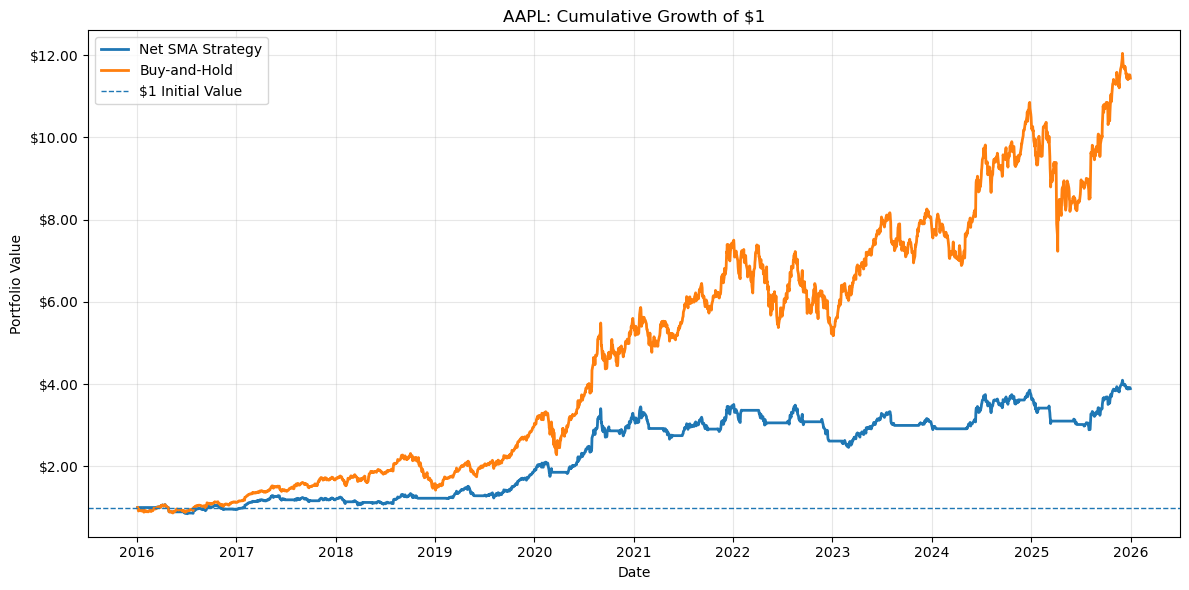

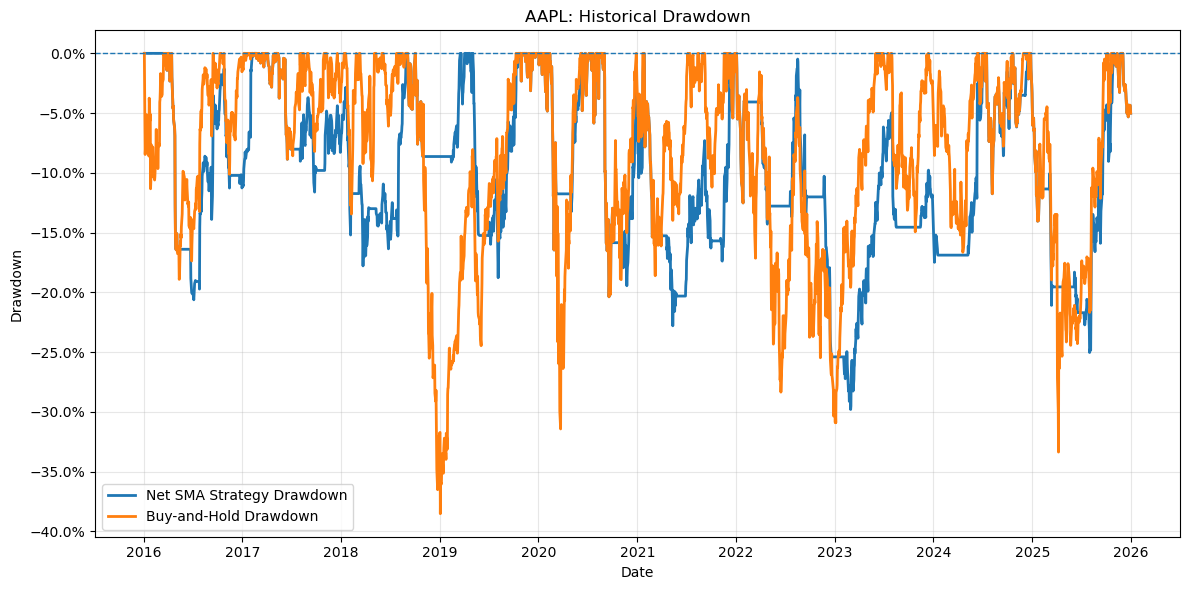

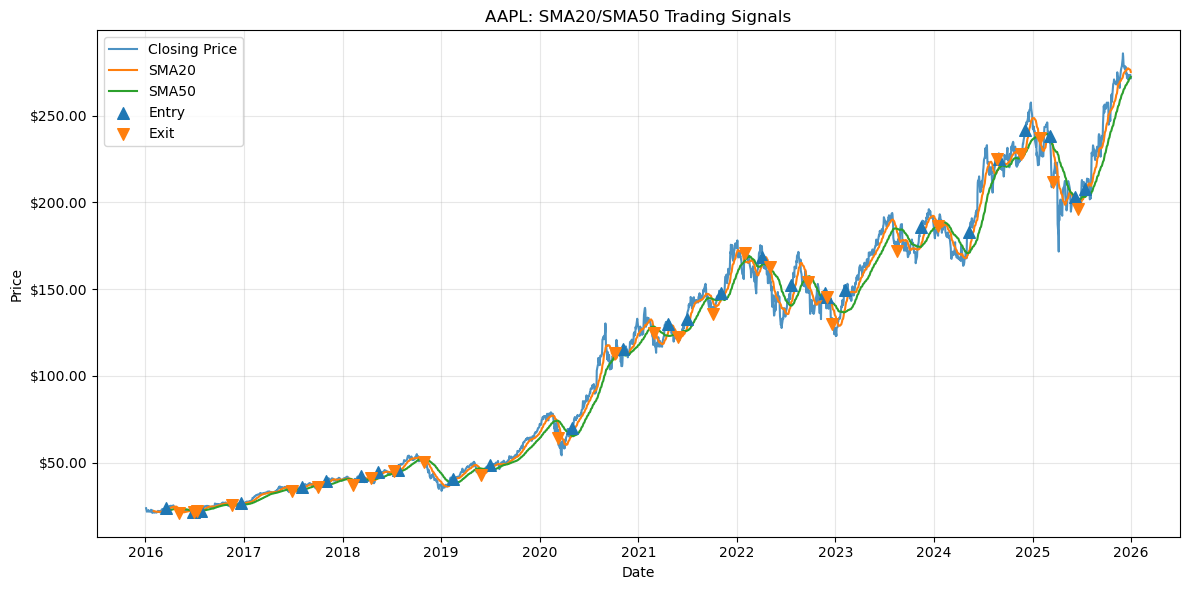

MSFT PERFORMANCE VISUALIZATIONS


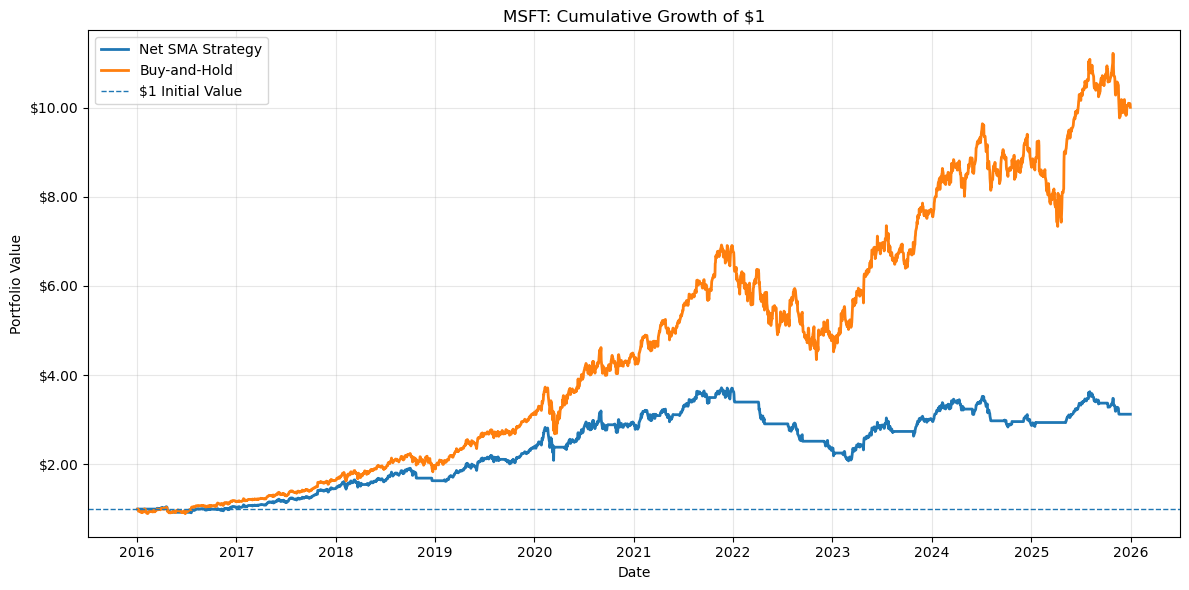

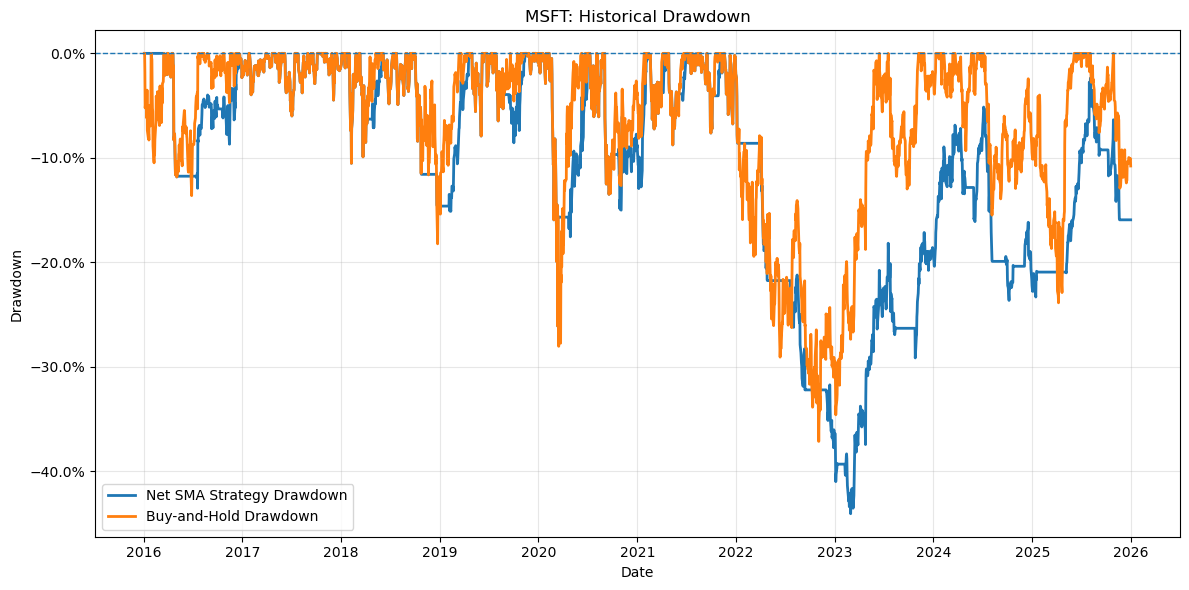

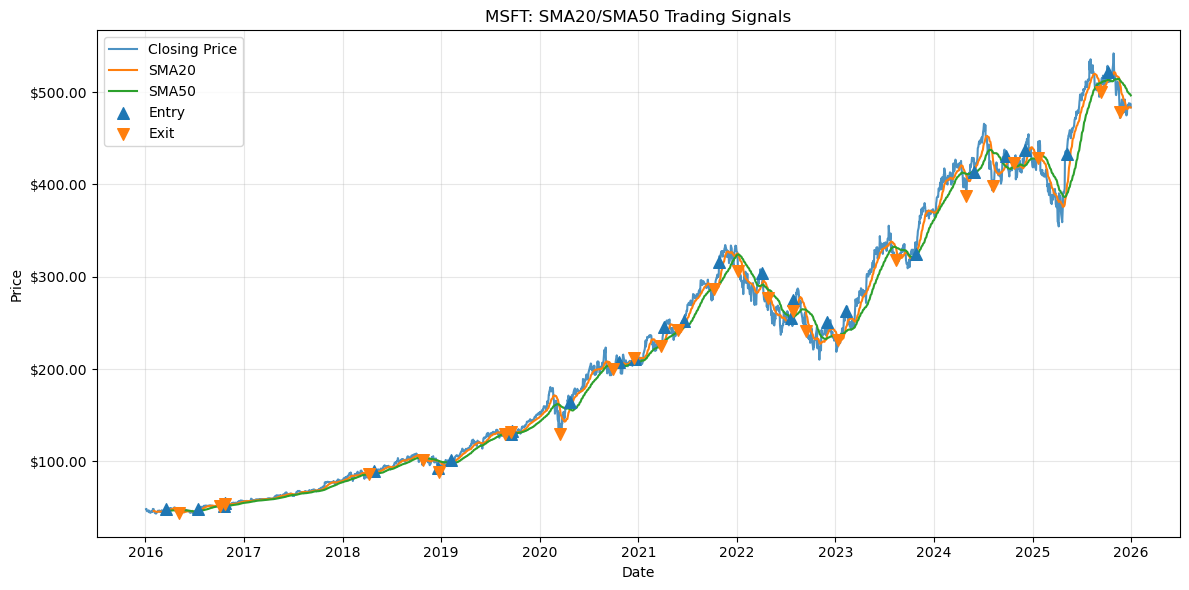

NVDA PERFORMANCE VISUALIZATIONS


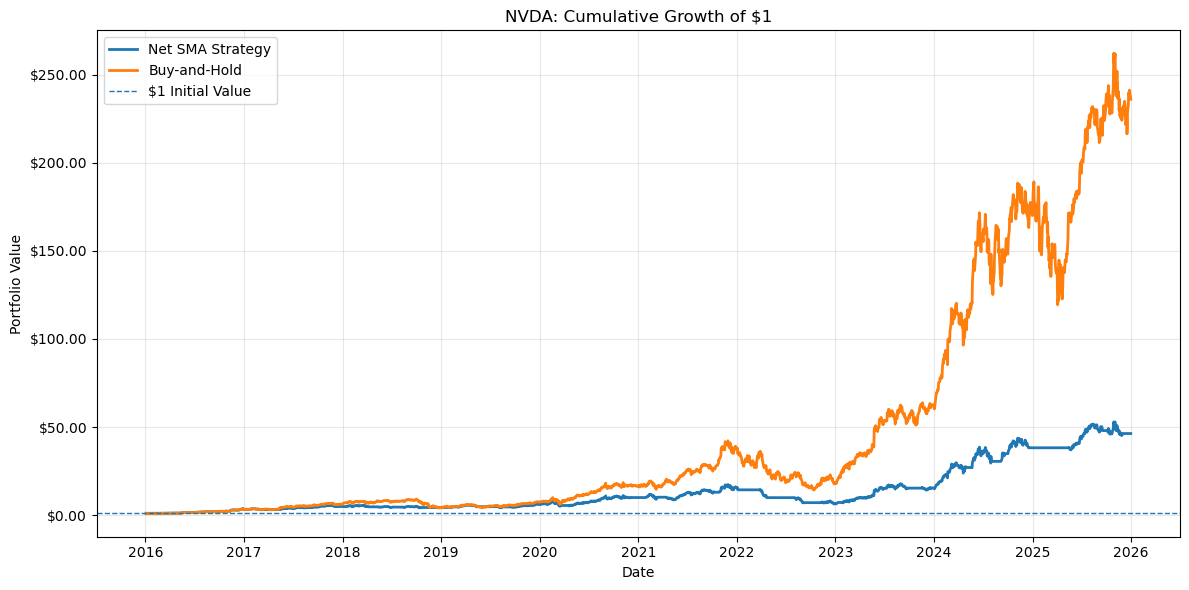

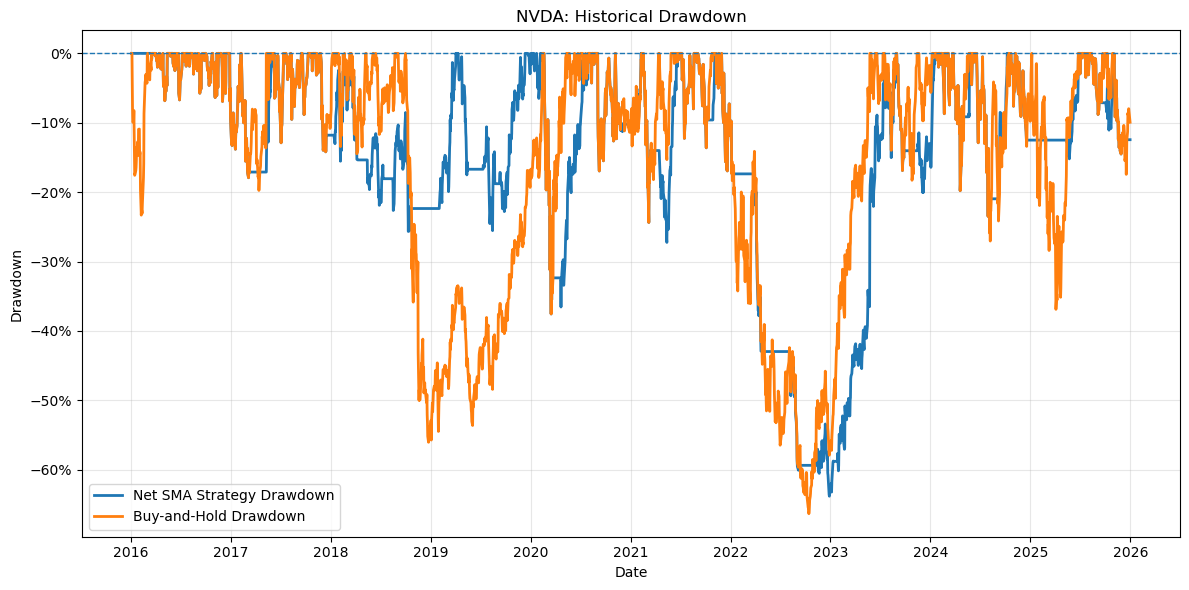

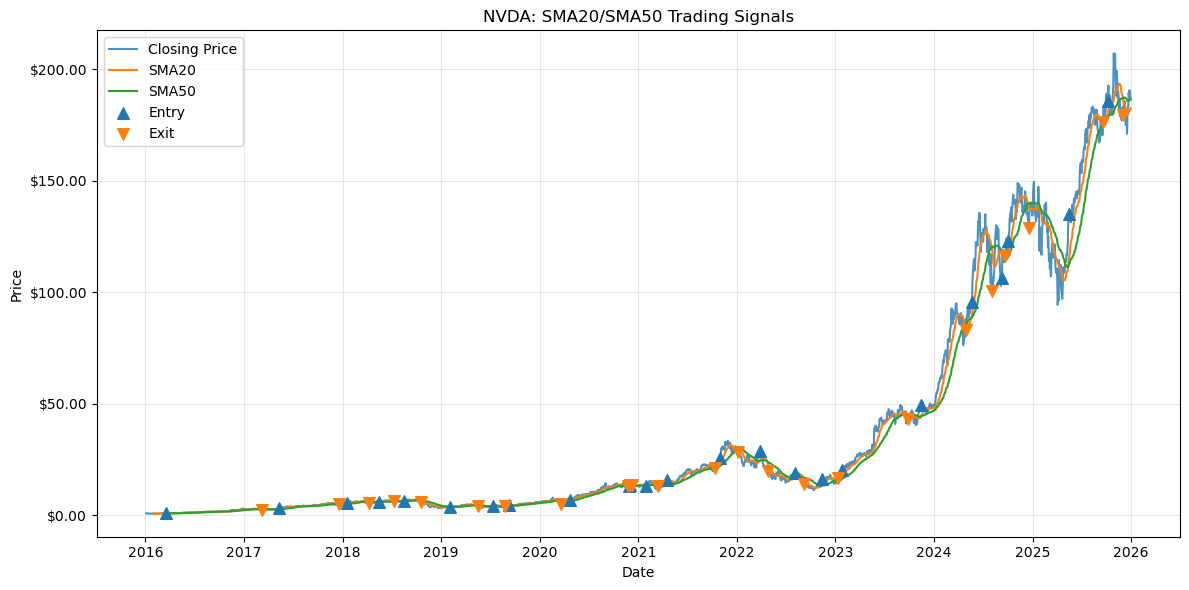

In [13]:
# =========================================================
# PART 11: PERFORMANCE VISUALIZATION
# =========================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import pandas as pd
from pathlib import Path


# ---------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------

TICKERS = ["AAPL", "MSFT", "NVDA"]

FIGURE_SIZE = (12, 6)

# Change to True to save charts in a local figures folder
SAVE_FIGURES = True

FIGURE_DIRECTORY = (
    Path.cwd()
    / "figures"
)

if SAVE_FIGURES:
    FIGURE_DIRECTORY.mkdir(
        parents=True,
        exist_ok=True
    )


# ---------------------------------------------------------
# 2. Select the visualization data
# ---------------------------------------------------------

# performance_data was created in Part 10.
# transaction_cost_data is used as a fallback.

if "performance_data" in globals():

    visualization_data = performance_data

elif "transaction_cost_data" in globals():

    visualization_data = transaction_cost_data

else:

    raise NameError(
        "Run Part 9 and Part 10 before running "
        "Part 11."
    )


# ---------------------------------------------------------
# 3. Required-column validation
# ---------------------------------------------------------

required_columns = [
    "Close",
    "SMA20",
    "SMA50",
    "Entry_Signal",
    "Exit_Signal",
    "Net_Strategy_Growth",
    "Buy_Hold_Growth",
    "Net_Strategy_Drawdown",
    "Buy_Hold_Drawdown"
]


for ticker in TICKERS:

    if ticker not in visualization_data:

        raise KeyError(
            f"{ticker} was not found in "
            "visualization_data."
        )

    missing_columns = [
        column
        for column in required_columns
        if column not in visualization_data[ticker].columns
    ]

    if missing_columns:

        raise KeyError(
            f"{ticker} is missing the following columns: "
            f"{missing_columns}"
        )


# ---------------------------------------------------------
# 4. Helper function for date-axis formatting
# ---------------------------------------------------------

def format_date_axis(axis):
    """
    Apply concise date formatting to a chart's x-axis.
    """

    date_locator = mdates.AutoDateLocator()

    date_formatter = mdates.ConciseDateFormatter(
        date_locator
    )

    axis.xaxis.set_major_locator(
        date_locator
    )

    axis.xaxis.set_major_formatter(
        date_formatter
    )


# ---------------------------------------------------------
# 5. Cumulative-growth chart function
# ---------------------------------------------------------

def plot_cumulative_growth(
    dataframe,
    ticker,
    save_figure=False
):
    """
    Plot the cumulative growth of $1 for the net SMA
    strategy and buy-and-hold benchmark.
    """

    df = dataframe.copy().sort_index()

    fig, ax = plt.subplots(
        figsize=FIGURE_SIZE
    )

    ax.plot(
        df.index,
        df["Net_Strategy_Growth"],
        label="Net SMA Strategy",
        linewidth=2
    )

    ax.plot(
        df.index,
        df["Buy_Hold_Growth"],
        label="Buy-and-Hold",
        linewidth=2
    )

    # Initial portfolio value
    ax.axhline(
        y=1.0,
        linestyle="--",
        linewidth=1,
        label="$1 Initial Value"
    )

    ax.set_title(
        f"{ticker}: Cumulative Growth of $1"
    )

    ax.set_xlabel(
        "Date"
    )

    ax.set_ylabel(
        "Portfolio Value"
    )

    ax.yaxis.set_major_formatter(
        mtick.StrMethodFormatter("${x:,.2f}")
    )

    format_date_axis(ax)

    ax.grid(
        True,
        alpha=0.3
    )

    ax.legend()

    fig.tight_layout()

    if save_figure:

        figure_path = (
            FIGURE_DIRECTORY
            / f"{ticker.lower()}_cumulative_growth.png"
        )

        fig.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


# ---------------------------------------------------------
# 6. Drawdown chart function
# ---------------------------------------------------------

def plot_drawdown(
    dataframe,
    ticker,
    save_figure=False
):
    """
    Plot the historical drawdowns for the net SMA
    strategy and buy-and-hold benchmark.
    """

    df = dataframe.copy().sort_index()

    fig, ax = plt.subplots(
        figsize=FIGURE_SIZE
    )

    ax.plot(
        df.index,
        df["Net_Strategy_Drawdown"],
        label="Net SMA Strategy Drawdown",
        linewidth=2
    )

    ax.plot(
        df.index,
        df["Buy_Hold_Drawdown"],
        label="Buy-and-Hold Drawdown",
        linewidth=2
    )

    ax.axhline(
        y=0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        f"{ticker}: Historical Drawdown"
    )

    ax.set_xlabel(
        "Date"
    )

    ax.set_ylabel(
        "Drawdown"
    )

    ax.yaxis.set_major_formatter(
        mtick.PercentFormatter(
            xmax=1.0
        )
    )

    format_date_axis(ax)

    ax.grid(
        True,
        alpha=0.3
    )

    ax.legend()

    fig.tight_layout()

    if save_figure:

        figure_path = (
            FIGURE_DIRECTORY
            / f"{ticker.lower()}_drawdown.png"
        )

        fig.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


# ---------------------------------------------------------
# 7. Price, SMA, entry, and exit chart function
# ---------------------------------------------------------

def plot_trading_signals(
    dataframe,
    ticker,
    save_figure=False
):
    """
    Plot closing price, SMA20, SMA50, and executable
    strategy entry and exit points.
    """

    df = dataframe.copy().sort_index()

    entry_rows = df.loc[
        df["Entry_Signal"] == 1
    ]

    exit_rows = df.loc[
        df["Exit_Signal"] == 1
    ]

    fig, ax = plt.subplots(
        figsize=FIGURE_SIZE
    )

    # Closing price
    ax.plot(
        df.index,
        df["Close"],
        label="Closing Price",
        linewidth=1.5,
        alpha=0.8
    )

    # Moving averages
    ax.plot(
        df.index,
        df["SMA20"],
        label="SMA20",
        linewidth=1.5
    )

    ax.plot(
        df.index,
        df["SMA50"],
        label="SMA50",
        linewidth=1.5
    )

    # Entry points
    ax.scatter(
        entry_rows.index,
        entry_rows["Close"],
        label="Entry",
        marker="^",
        s=70,
        zorder=5
    )

    # Exit points
    ax.scatter(
        exit_rows.index,
        exit_rows["Close"],
        label="Exit",
        marker="v",
        s=70,
        zorder=5
    )

    ax.set_title(
        f"{ticker}: SMA20/SMA50 Trading Signals"
    )

    ax.set_xlabel(
        "Date"
    )

    ax.set_ylabel(
        "Price"
    )

    ax.yaxis.set_major_formatter(
        mtick.StrMethodFormatter("${x:,.2f}")
    )

    format_date_axis(ax)

    ax.grid(
        True,
        alpha=0.3
    )

    ax.legend()

    fig.tight_layout()

    if save_figure:

        figure_path = (
            FIGURE_DIRECTORY
            / f"{ticker.lower()}_trading_signals.png"
        )

        fig.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


# ---------------------------------------------------------
# 8. Produce all charts for AAPL, MSFT, and NVDA
# ---------------------------------------------------------

for ticker in TICKERS:

    ticker_data = (
        visualization_data[ticker]
        .copy()
        .sort_index()
    )

    print(
        "=" * 70
    )

    print(
        f"{ticker} PERFORMANCE VISUALIZATIONS"
    )

    print(
        "=" * 70
    )

    # Chart 1: cumulative growth
    plot_cumulative_growth(
        dataframe=ticker_data,
        ticker=ticker,
        save_figure=SAVE_FIGURES
    )

    # Chart 2: drawdown
    plot_drawdown(
        dataframe=ticker_data,
        ticker=ticker,
        save_figure=SAVE_FIGURES
    )

    # Chart 3: price and trading signals
    plot_trading_signals(
        dataframe=ticker_data,
        ticker=ticker,
        save_figure=SAVE_FIGURES
    )



### Performance-Visualization Results

The cumulative-growth charts compare the historical growth of one dollar under
the transaction-cost-adjusted SMA20/SMA50 strategy and the buy-and-hold
benchmark.

Buy-and-hold generated substantially greater cumulative wealth for AAPL, MSFT,
and NVDA during the sample period. The difference became particularly large
during extended bullish periods because buy-and-hold remained continuously
invested, while the SMA strategy moved into cash whenever the short-term moving
average fell below the long-term moving average.

The drawdown charts show whether the SMA strategy reduced the magnitude or
duration of historical losses. Although the strategy avoided some periods of
market decline, the reduction in drawdown was not consistent across all three
assets.

The price and moving-average charts confirm that entries occurred after SMA20
moved above SMA50 and exits occurred after SMA20 moved below SMA50. Because the
strategy used the previous day's signal as the next day's executable position,
the implementation avoided look-ahead bias.

The charts also illustrate the lagging nature of moving-average signals.
Entries generally occurred after an upward price movement had already begun,
while exits occurred after part of a decline had already taken place.

Overall, the visual evidence is consistent with the numerical performance
metrics. The SMA strategy reduced market exposure but sacrificed a substantial
amount of long-term return compared with buy-and-hold.

## Part 12: Train-Test Split and Out-of-Sample Evaluation

The previous sections evaluated the SMA20/SMA50 strategy over the complete
historical sample. However, evaluating a strategy on the same data used to
select its rules can produce overly optimistic conclusions.

This section divides the data into:

- A training period
- A testing period

The training period is used to examine and develop the strategy. The testing
period is reserved for out-of-sample evaluation and is not used to modify the
strategy rules.

For this project, the sample is divided chronologically rather than randomly
because financial time-series observations must preserve their original order.

The strategy's net performance will be compared with buy-and-hold separately
during the training and testing periods using:

- Total return
- Annualized return
- Annualized volatility
- Sharpe ratio
- Maximum drawdown

The out-of-sample results provide a more realistic indication of whether the
strategy's historical behavior persists on previously unseen data.

In [14]:
# =========================================================
# PART 12: CHRONOLOGICAL TRAIN-TEST SPLIT
# AND OUT-OF-SAMPLE EVALUATION
# =========================================================

import numpy as np
import pandas as pd
from IPython.display import display


# ---------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------

TRADING_DAYS = 252
RISK_FREE_RATE = 0.04

TICKERS = [
    "AAPL",
    "MSFT",
    "NVDA"
]

TRAIN_START = pd.Timestamp("2016-01-01")
TRAIN_END = pd.Timestamp("2021-12-31")

TEST_START = pd.Timestamp("2022-01-01")
TEST_END = pd.Timestamp("2025-12-31")


# ---------------------------------------------------------
# 2. Select the full-history strategy data
# ---------------------------------------------------------

# The strategy must be calculated over the complete chronological
# history before the train-test split.
#
# transaction_cost_data was created in Part 9.
# performance_data was created in Part 10 and is used as a fallback.

if "transaction_cost_data" in globals():

    full_backtest_data = transaction_cost_data

elif "performance_data" in globals():

    full_backtest_data = performance_data

else:

    raise NameError(
        "Run Parts 9 and 10 before running Part 12. "
        "Neither transaction_cost_data nor performance_data exists."
    )


# ---------------------------------------------------------
# 3. Performance-metric function
# ---------------------------------------------------------

def calculate_period_metrics(
    return_series,
    trading_days=252,
    risk_free_rate=0.04
):
    """
    Calculate performance metrics for one chronological period.

    Parameters
    ----------
    return_series : pandas.Series
        Daily strategy or benchmark returns.

    trading_days : int
        Assumed number of trading days per year.

    risk_free_rate : float
        Annual risk-free rate.

    Returns
    -------
    dict
        Total return, annualized return, annualized volatility,
        Sharpe ratio, maximum drawdown, and observation count.
    """

    returns = (
        return_series
        .dropna()
        .astype(float)
        .sort_index()
    )

    if returns.empty:

        raise ValueError(
            "The selected period contains no valid return observations."
        )

    if (returns <= -1).any():

        raise ValueError(
            "The return series contains a daily return less than "
            "or equal to -100%."
        )

    observation_count = len(returns)

    # -----------------------------------------------------
    # Cumulative growth
    # -----------------------------------------------------

    growth = (
        1 + returns
    ).cumprod()

    # -----------------------------------------------------
    # Total return
    # -----------------------------------------------------

    total_return = (
        growth.iloc[-1] - 1
    )

    # -----------------------------------------------------
    # Annualized return
    # -----------------------------------------------------

    annualized_return = (
        growth.iloc[-1]
        ** (
            trading_days
            / observation_count
        )
        - 1
    )

    # -----------------------------------------------------
    # Annualized volatility
    # -----------------------------------------------------

    annualized_volatility = (
        returns.std(ddof=1)
        * np.sqrt(trading_days)
    )

    # -----------------------------------------------------
    # Sharpe ratio using daily excess returns
    # -----------------------------------------------------
    
    daily_volatility = returns.std(ddof=1)

    daily_risk_free_rate = (
      (1 + risk_free_rate)
      ** (1 / trading_days)
      - 1
    )

    daily_excess_returns = (
      returns
      - daily_risk_free_rate
    )

    if (
        pd.isna(daily_volatility)
        or np.isclose(daily_volatility, 0.0)
    ):
        sharpe_ratio = np.nan

    else:
        sharpe_ratio = (
         daily_excess_returns.mean()
         / daily_volatility
         * np.sqrt(trading_days)
        )

    # -----------------------------------------------------
    # Maximum drawdown
    # -----------------------------------------------------

    # Include the initial portfolio value of 1.0 as the
    # first possible running peak.
    running_peak = (
        growth
        .cummax()
        .clip(lower=1.0)
    )

    drawdown = (
        growth
        / running_peak
        - 1
    )

    maximum_drawdown = (
        drawdown.min()
    )

    return {
        "Total Return":
            total_return,

        "Annualized Return":
            annualized_return,

        "Annualized Volatility":
            annualized_volatility,

        "Sharpe Ratio":
            sharpe_ratio,

        "Maximum Drawdown":
            maximum_drawdown,

        "Observations":
            observation_count,

        "Growth":
            growth,

        "Drawdown":
            drawdown
    }


# ---------------------------------------------------------
# 4. Helper function for one ticker and one period
# ---------------------------------------------------------

def evaluate_period(
    dataframe,
    ticker,
    period_name,
    start_date,
    end_date
):
    """
    Evaluate the net SMA strategy and gross buy-and-hold
    benchmark during one chronological period.
    """

    df = (
        dataframe
        .copy()
        .sort_index()
    )

    if not isinstance(
        df.index,
        pd.DatetimeIndex
    ):

        raise TypeError(
            f"{ticker} does not have a DatetimeIndex."
        )

    required_columns = [
        "Net_Strategy_Return",
        "Buy_Hold_Return",
        "Position",
        "Trade"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:

        raise KeyError(
            f"{ticker} is missing the following columns: "
            f"{missing_columns}"
        )

    # -----------------------------------------------------
    # Chronological period selection
    # -----------------------------------------------------

    period_df = df.loc[
        (df.index >= start_date)
        & (df.index <= end_date)
    ].copy()

    if period_df.empty:

        raise ValueError(
            f"{ticker} contains no data for {period_name}: "
            f"{start_date.date()} to {end_date.date()}."
        )

    # -----------------------------------------------------
    # Performance calculations
    # -----------------------------------------------------

    net_strategy_metrics = (
        calculate_period_metrics(
            return_series=period_df[
                "Net_Strategy_Return"
            ],
            trading_days=TRADING_DAYS,
            risk_free_rate=RISK_FREE_RATE
        )
    )

    buy_hold_metrics = (
        calculate_period_metrics(
            return_series=period_df[
                "Buy_Hold_Return"
            ],
            trading_days=TRADING_DAYS,
            risk_free_rate=RISK_FREE_RATE
        )
    )

    # -----------------------------------------------------
    # Period-specific growth and drawdown
    # -----------------------------------------------------

    period_df["Period_Net_Strategy_Growth"] = (
        1
        + period_df[
            "Net_Strategy_Return"
        ].fillna(0)
    ).cumprod()

    period_df["Period_Buy_Hold_Growth"] = (
        1
        + period_df[
            "Buy_Hold_Return"
        ].fillna(0)
    ).cumprod()

    period_df["Period_Net_Strategy_Peak"] = (
        period_df[
            "Period_Net_Strategy_Growth"
        ]
        .cummax()
        .clip(lower=1.0)
    )

    period_df["Period_Buy_Hold_Peak"] = (
        period_df[
            "Period_Buy_Hold_Growth"
        ]
        .cummax()
        .clip(lower=1.0)
    )

    period_df["Period_Net_Strategy_Drawdown"] = (
        period_df[
            "Period_Net_Strategy_Growth"
        ]
        / period_df[
            "Period_Net_Strategy_Peak"
        ]
        - 1
    )

    period_df["Period_Buy_Hold_Drawdown"] = (
        period_df[
            "Period_Buy_Hold_Growth"
        ]
        / period_df[
            "Period_Buy_Hold_Peak"
        ]
        - 1
    )

    # -----------------------------------------------------
    # Strategy diagnostics
    # -----------------------------------------------------

    valid_strategy_dates = (
        period_df[
            "Net_Strategy_Return"
        ]
        .notna()
    )

    market_exposure = (
        period_df.loc[
            valid_strategy_dates,
            "Position"
        ]
        .mean()
    )

    transaction_count = int(
        period_df[
            "Trade"
        ]
        .fillna(0)
        .sum()
    )

    entry_count = (
        int(
            period_df[
                "Entry_Signal"
            ]
            .fillna(0)
            .sum()
        )
        if "Entry_Signal" in period_df.columns
        else np.nan
    )

    exit_count = (
        int(
            period_df[
                "Exit_Signal"
            ]
            .fillna(0)
            .sum()
        )
        if "Exit_Signal" in period_df.columns
        else np.nan
    )

    completed_round_trips = (
        min(
            entry_count,
            exit_count
        )
        if (
            not pd.isna(entry_count)
            and not pd.isna(exit_count)
        )
        else np.nan
    )

    start_position = int(
        period_df[
            "Position"
        ].iloc[0]
    )

    final_position = int(
        period_df[
            "Position"
        ].iloc[-1]
    )

    # -----------------------------------------------------
    # Summary row
    # -----------------------------------------------------

    summary_row = {
        "Ticker":
            ticker,

        "Period":
            period_name,

        "Requested Start":
            start_date,

        "Requested End":
            end_date,

        "Actual Start":
            period_df.index.min(),

        "Actual End":
            period_df.index.max(),

        "Net Total Return":
            net_strategy_metrics[
                "Total Return"
            ],

        "Gross Buy-and-Hold Total Return":
            buy_hold_metrics[
                "Total Return"
            ],

        "Net Annualized Return":
            net_strategy_metrics[
                "Annualized Return"
            ],

        "Gross Buy-and-Hold Annualized Return":
            buy_hold_metrics[
                "Annualized Return"
            ],

        "Net Annualized Volatility":
            net_strategy_metrics[
                "Annualized Volatility"
            ],

        "Gross Buy-and-Hold Annualized Volatility":
            buy_hold_metrics[
                "Annualized Volatility"
            ],

        "Net Sharpe Ratio":
            net_strategy_metrics[
                "Sharpe Ratio"
            ],

        "Gross Buy-and-Hold Sharpe Ratio":
            buy_hold_metrics[
                "Sharpe Ratio"
            ],

        "Net Maximum Drawdown":
            net_strategy_metrics[
                "Maximum Drawdown"
            ],

        "Gross Buy-and-Hold Maximum Drawdown":
            buy_hold_metrics[
                "Maximum Drawdown"
            ],

        "Market Exposure":
            market_exposure,

        "Transactions":
            transaction_count,

        "Entries":
            entry_count,

        "Exits":
            exit_count,

        "Completed Round Trips":
            completed_round_trips,

        "Starting Position":
            start_position,

        "Final Position":
            final_position,

        "Valid Return Observations":
            net_strategy_metrics[
                "Observations"
            ]
    }

    return period_df, summary_row


# ---------------------------------------------------------
# 5. Evaluate training and testing periods
# ---------------------------------------------------------

train_test_data = {}
summary_rows = []


for ticker in TICKERS:

    if ticker not in full_backtest_data:

        raise KeyError(
            f"{ticker} was not found in full_backtest_data."
        )

    ticker_df = (
        full_backtest_data[ticker]
        .copy()
        .sort_index()
    )

    # -----------------------------------------------------
    # Training period
    # -----------------------------------------------------

    train_df, train_summary = (
        evaluate_period(
            dataframe=ticker_df,
            ticker=ticker,
            period_name="Training",
            start_date=TRAIN_START,
            end_date=TRAIN_END
        )
    )

    # -----------------------------------------------------
    # Testing period
    # -----------------------------------------------------

    test_df, test_summary = (
        evaluate_period(
            dataframe=ticker_df,
            ticker=ticker,
            period_name="Testing",
            start_date=TEST_START,
            end_date=TEST_END
        )
    )

    train_test_data[ticker] = {
        "Training": train_df,
        "Testing": test_df
    }

    summary_rows.append(
        train_summary
    )

    summary_rows.append(
        test_summary
    )

    
  

# ---------------------------------------------------------
# 6. Individual DataFrame references
# ---------------------------------------------------------

aapl_train = train_test_data["AAPL"]["Training"]
aapl_test = train_test_data["AAPL"]["Testing"]

msft_train = train_test_data["MSFT"]["Training"]
msft_test = train_test_data["MSFT"]["Testing"]

nvda_train = train_test_data["NVDA"]["Training"]
nvda_test = train_test_data["NVDA"]["Testing"]


# ---------------------------------------------------------
# 7. Complete train-test summary
# ---------------------------------------------------------

train_test_summary = (
    pd.DataFrame(summary_rows)
    .set_index([
        "Ticker",
        "Period"
    ])
    .sort_index()
)


# ---------------------------------------------------------
# 8. Separate training and testing tables
# ---------------------------------------------------------

training_summary = (
    train_test_summary
    .xs(
        "Training",
        level="Period"
    )
    .copy()
)

testing_summary = (
    train_test_summary
    .xs(
        "Testing",
        level="Period"
    )
    .copy()
)


# ---------------------------------------------------------
# 9. Formatting dictionaries
# ---------------------------------------------------------

percentage_columns = {
    "Net Total Return": "{:.2%}",

    "Gross Buy-and-Hold Total Return":
        "{:.2%}",

    "Net Annualized Return":
        "{:.2%}",

    "Gross Buy-and-Hold Annualized Return":
        "{:.2%}",

    "Net Annualized Volatility":
        "{:.2%}",

    "Gross Buy-and-Hold Annualized Volatility":
        "{:.2%}",

    "Net Maximum Drawdown":
        "{:.2%}",

    "Gross Buy-and-Hold Maximum Drawdown":
        "{:.2%}",

    "Market Exposure":
        "{:.2%}"
}

ratio_columns = {
    "Net Sharpe Ratio":
        "{:.3f}",

    "Gross Buy-and-Hold Sharpe Ratio":
        "{:.3f}"
}

integer_columns = {
    "Transactions":
        "{:.0f}",

    "Entries":
        "{:.0f}",

    "Exits":
        "{:.0f}",

    "Completed Round Trips":
        "{:.0f}",

    "Starting Position":
        "{:.0f}",

    "Final Position":
        "{:.0f}",

    "Valid Return Observations":
        "{:.0f}"
}

date_columns = {
    "Requested Start":
        lambda value: value.strftime("%Y-%m-%d"),

    "Requested End":
        lambda value: value.strftime("%Y-%m-%d"),

    "Actual Start":
        lambda value: value.strftime("%Y-%m-%d"),

    "Actual End":
        lambda value: value.strftime("%Y-%m-%d")
}

summary_format = {
    **percentage_columns,
    **ratio_columns,
    **integer_columns,
    **date_columns
}


# ---------------------------------------------------------
# 10. Display training-period table
# ---------------------------------------------------------

print("=" * 80)
print("TRAINING-PERIOD PERFORMANCE")
print("=" * 80)

display(
    training_summary.style.format(
        summary_format
    )
)


# ---------------------------------------------------------
# 11. Display testing-period table
# ---------------------------------------------------------

print("=" * 80)
print("TESTING-PERIOD OUT-OF-SAMPLE PERFORMANCE")
print("=" * 80)

display(
    testing_summary.style.format(
        summary_format
    )
)


# ---------------------------------------------------------
# 12. Compact train-versus-test comparison
# ---------------------------------------------------------

comparison_metrics = [
    "Net Annualized Return",
    "Gross Buy-and-Hold Annualized Return",
    "Net Annualized Volatility",
    "Gross Buy-and-Hold Annualized Volatility",
    "Net Sharpe Ratio",
    "Gross Buy-and-Hold Sharpe Ratio",
    "Net Maximum Drawdown",
    "Gross Buy-and-Hold Maximum Drawdown",
    "Market Exposure"
]


comparison_rows = []


for ticker in TICKERS:

    for metric in comparison_metrics:

        training_value = (
            train_test_summary.loc[
                (ticker, "Training"),
                metric
            ]
        )

        testing_value = (
            train_test_summary.loc[
                (ticker, "Testing"),
                metric
            ]
        )

        comparison_rows.append({
            "Ticker":
                ticker,

            "Metric":
                metric,

            "Training":
                training_value,

            "Testing":
                testing_value,

            "Testing Minus Training":
                testing_value
                - training_value
        })


train_test_comparison = (
    pd.DataFrame(comparison_rows)
    .set_index([
        "Ticker",
        "Metric"
    ])
)


def comparison_formatter(value):

    if pd.isna(value):
        return "NaN"

    return f"{value:.3f}"


print("=" * 80)
print("TRAIN-VERSUS-TEST COMPARISON")
print("=" * 80)

display(
    train_test_comparison.style.format(
        comparison_formatter
    )
)


# ---------------------------------------------------------
# 13. Sample-boundary validation
# ---------------------------------------------------------

boundary_rows = []


for ticker in TICKERS:

    train_df = (
        train_test_data[ticker]["Training"]
    )

    test_df = (
        train_test_data[ticker]["Testing"]
    )

    boundary_rows.append({
        "Ticker":
            ticker,

        "Training Final Date":
            train_df.index.max(),

        "Testing First Date":
            test_df.index.min(),

        "Training Final Position":
            int(
                train_df[
                    "Position"
                ].iloc[-1]
            ),

        "Testing Initial Position":
            int(
                test_df[
                    "Position"
                ].iloc[0]
            ),

        "Chronological Order Valid":
            bool(
                train_df.index.max()
                < test_df.index.min()
            )
    })


split_validation = (
    pd.DataFrame(boundary_rows)
    .set_index("Ticker")
)


display(
    split_validation.style.format({
        "Training Final Date":
            lambda value:
                value.strftime("%Y-%m-%d"),

        "Testing First Date":
            lambda value:
                value.strftime("%Y-%m-%d"),

        "Training Final Position":
            "{:.0f}",

        "Testing Initial Position":
            "{:.0f}"
    })
)

TRAINING-PERIOD PERFORMANCE


,Requested Start,Requested End,Actual Start,Actual End,Net Total Return,Gross Buy-and-Hold Total Return,Net Annualized Return,Gross Buy-and-Hold Annualized Return,Net Annualized Volatility,Gross Buy-and-Hold Annualized Volatility,Net Sharpe Ratio,Gross Buy-and-Hold Sharpe Ratio,Net Maximum Drawdown,Gross Buy-and-Hold Maximum Drawdown,Market Exposure,Transactions,Entries,Exits,Completed Round Trips,Starting Position,Final Position,Valid Return Observations
Ticker,,,,,,,,,,,,,,,,,,,,,,
AAPL,2016-01-01,2021-12-31,2016-01-04,2021-12-31,242.15%,632.07%,22.77%,39.41%,21.42%,29.38%,0.882,1.145,-22.80%,-38.52%,69.76%,33,17,16,16,0,1,1511
MSFT,2016-01-01,2021-12-31,2016-01-04,2021-12-31,264.53%,578.19%,24.07%,37.64%,21.71%,26.74%,0.922,1.183,-26.11%,-28.04%,80.74%,29,15,14,14,0,1,1511
NVDA,2016-01-01,2021-12-31,2016-01-04,2021-12-31,1428.13%,3617.44%,57.58%,82.83%,39.08%,47.08%,1.257,1.433,-37.56%,-56.04%,75.05%,27,14,13,13,0,1,1511


TESTING-PERIOD OUT-OF-SAMPLE PERFORMANCE


,Requested Start,Requested End,Actual Start,Actual End,Net Total Return,Gross Buy-and-Hold Total Return,Net Annualized Return,Gross Buy-and-Hold Annualized Return,Net Annualized Volatility,Gross Buy-and-Hold Annualized Volatility,Net Sharpe Ratio,Gross Buy-and-Hold Sharpe Ratio,Net Maximum Drawdown,Gross Buy-and-Hold Maximum Drawdown,Market Exposure,Transactions,Entries,Exits,Completed Round Trips,Starting Position,Final Position,Valid Return Observations
Ticker,,,,,,,,,,,,,,,,,,,,,,
AAPL,2022-01-01,2025-12-31,2022-01-03,2025-12-31,13.73%,56.32%,3.28%,11.88%,18.08%,28.54%,0.052,0.398,-29.80%,-33.36%,57.13%,24,12,12,12,1,1,1003
MSFT,2022-01-01,2025-12-31,2022-01-03,2025-12-31,-14.24%,47.53%,-3.79%,10.26%,16.74%,26.77%,-0.381,0.352,-42.94%,-35.88%,54.84%,23,11,12,11,1,0,1003
NVDA,2022-01-01,2025-12-31,2022-01-03,2025-12-31,202.97%,535.17%,32.11%,59.12%,38.10%,53.88%,0.814,1.056,-59.91%,-62.70%,60.42%,21,10,11,10,1,0,1003


TRAIN-VERSUS-TEST COMPARISON


,Training Final Date,Testing First Date,Training Final Position,Testing Initial Position,Chronological Order Valid
Ticker,,,,,
AAPL,2021-12-31,2022-01-03,1,1,True
MSFT,2021-12-31,2022-01-03,1,1,True
NVDA,2021-12-31,2022-01-03,1,1,True


### Out-of-Sample Evaluation Results

The historical sample was divided chronologically into:

- **Training period:** January 2016 to December 2021
- **Testing period:** January 2022 to December 2025

The training period is longer than the testing period because it provides more
observations and market conditions for evaluating the SMA20/SMA50 strategy.

The testing period was treated as out-of-sample data. The strategy parameters
were kept unchanged during this period:

- Short moving-average window: 20 trading days
- Long moving-average window: 50 trading days
- Transaction cost: 0.1% per entry or exit
- Annual risk-free rate: 4%

The data were divided chronologically rather than randomly because financial
time-series observations must remain in their original order.

### Training-versus-Testing Comparison

The training and testing periods were compared using:

- Net total return
- Net annualized return
- Net annualized volatility
- Net Sharpe ratio
- Net maximum drawdown
- Market exposure
- Number of transactions

The same metrics were also calculated for the gross buy-and-hold benchmark.

Differences between the training and testing results indicate that strategy
performance depends on the market conditions present during each period. A
strategy may perform well during one market regime but perform less effectively
during another.

### Sharpe Ratio

The Sharpe ratio is calculated using the average daily excess return and is
annualized using the square-root-of-time rule:

\[
\text{Sharpe Ratio}
=
\frac{\overline{r_t-r_{f,d}}}
{\sigma_d}
\sqrt{252}
\]

where:

- \(r_t\) is the daily strategy or benchmark return
- \(r_{f,d}\) is the daily risk-free return
- \(\overline{r_t-r_{f,d}}\) is the average daily excess return
- \(\sigma_d\) is the standard deviation of daily returns
- 252 is the assumed number of trading days per year

The daily risk-free return is converted from the assumed annual risk-free rate:

\[
r_{f,d}
=
(1+R_f)^{1/252}-1
\]

This project assumes:

\[
R_f=0.04=4\%
\]

The same Sharpe-ratio methodology is applied to the net SMA strategy and the
buy-and-hold benchmark.

A positive Sharpe ratio indicates that the strategy generated a positive average
daily excess return relative to its daily-return volatility.

A negative Sharpe ratio indicates that the average daily return was below the
daily risk-free return after accounting for volatility.

### Out-of-Sample Interpretation

The testing-period results provide a more realistic evaluation than the
full-sample results because the testing data were not used to modify the
strategy parameters.

Strong training-period performance followed by substantially weaker testing
performance may indicate that the strategy is sensitive to market regime
changes or that its historical performance is not stable.

Similar performance across training and testing periods would provide some
evidence of robustness. However, a single chronological split is not sufficient
to prove that the strategy will remain profitable in the future.

The SMA strategy should be evaluated relative to buy-and-hold using both return
and risk measures. Lower strategy returns may still provide value when
accompanied by meaningfully lower volatility or maximum drawdown. However, a
small reduction in risk may not compensate for substantially lower returns or a
weaker Sharpe ratio.

Overall, the out-of-sample results should be interpreted as evidence about the
historical stability of the SMA20/SMA50 strategy rather than as a prediction of
future performance.

## Part 13: Limitations

This backtest provides a structured historical evaluation of the SMA20/SMA50
crossover strategy, but several limitations must be considered when interpreting
the results.

### 1. Historical Performance Does Not Guarantee Future Results

The strategy was evaluated using historical prices from 2016 to 2025.

Market structure, volatility, interest rates, investor behavior, and company
fundamentals may change over time. Therefore, historical profitability or
risk reduction does not guarantee similar performance in the future.

### 2. Limited Asset Sample

The analysis includes only:

- AAPL
- MSFT
- NVDA

These are large technology-oriented companies that experienced substantial
long-term price appreciation during the sample period.

The conclusions may not generalize to:

- Other sectors
- Smaller companies
- International equities
- Market indices
- Bonds, commodities, or cryptocurrencies

Testing only three successful companies may also introduce asset-selection
bias.

### 3. Strong Bull-Market Influence

Much of the sample contained strong long-term upward trends.

Buy-and-hold tends to perform particularly well during persistent bull markets
because it remains continuously invested. The SMA strategy moved into cash
during some periods and therefore missed portions of these price increases.

The relative performance could differ during prolonged bear markets or
sideways markets.

### 4. Simplified Execution Assumption

The strategy uses the previous trading day's signal as the current day's
position:

\[
\text{Position}_t
=
\text{Signal}_{t-1}
\]

This prevents direct look-ahead bias. However, the return calculation assumes
that the position receives the complete current-day close-to-close return.

In practice, an investor observing the previous closing-price signal may execute
at the next market open rather than at the previous close. Overnight price gaps
and intraday price movements could therefore cause realized returns to differ
from the backtest.

A more execution-specific model would use next-day opening prices and calculate
returns according to the assumed trade time.

### 5. Simplified Transaction Costs

The backtest assumes a fixed transaction cost of:

\[
c=0.001=0.1\%
\]

on every entry and exit.

Actual trading costs may include:

- Bid-ask spreads
- Brokerage fees
- Slippage
- Market impact
- Taxes
- Different costs across assets and market conditions

A fixed rate does not capture changes in liquidity or volatility.

### 6. Gross Buy-and-Hold Benchmark

The SMA strategy is evaluated after transaction costs, while the buy-and-hold
benchmark is reported as a gross benchmark.

Buy-and-hold would normally incur an initial purchase cost and possibly a final
sale cost. Because it trades only once or twice, the effect would likely be
small relative to the SMA strategy's repeated transaction costs.

Nevertheless, a fully consistent comparison would calculate both net SMA and
net buy-and-hold performance.

### 7. Cash Return Is Assumed to Be Zero

Whenever:

\[
\text{Position}_t=0
\]

the strategy is assumed to remain in cash and earn a daily return of zero.

In practice, unused cash could earn interest through Treasury bills, money-market
funds, or other short-term instruments.

Ignoring cash interest may understate the SMA strategy's return, especially
during periods with high interest rates.

### 8. Constant Risk-Free Rate

The project assumes a constant annual risk-free rate of:

\[
R_f=4\%
\]

Actual risk-free rates changed throughout the 2016–2025 period.

Using one constant rate simplifies the Sharpe-ratio calculation but does not
represent the interest-rate conditions of every year in the sample.

A more detailed analysis could use a time-varying Treasury-bill rate.

### 9. Dividend Treatment

The downloaded CSV files contain closing prices but do not provide an explicit
dividend or total-return field.

The project therefore treats the analysis as a price-return backtest. If the
closing-price series does not fully incorporate dividends, buy-and-hold returns
and strategy returns may be understated.

A total-return dataset with verified dividend adjustments would provide a more
complete performance comparison.

### 10. Corporate-Action and Data-Quality Assumptions

The data were checked for obvious unadjusted stock splits using extreme daily
returns, and no one-day price changes above the selected threshold were found.

However, this diagnostic does not independently prove that every corporate
action was handled correctly.

The reliability of the backtest remains dependent on the accuracy and adjustment
methodology of the original data source.

### 11. Binary Long-Only Position

The strategy uses only two possible positions:

- `Position = 1`: fully invested
- `Position = 0`: fully in cash

The model does not include:

- Short selling
- Partial position sizes
- Leverage
- Volatility targeting
- Portfolio allocation across several assets
- Stop-loss or take-profit rules

The results therefore apply only to a simple long-only crossover strategy.

### 12. Fixed SMA20/SMA50 Parameters

The project evaluates a predetermined SMA20/SMA50 strategy.

It does not search for the historically optimal moving-average windows. This
reduces the risk of parameter overfitting but also means that other crossover
parameters may produce different results.

The conclusion should therefore apply specifically to SMA20/SMA50 rather than
to every possible moving-average strategy.

### 13. Single Train-Test Split

The sample was divided into one chronological training period and one testing
period:

- Training: 2016–2021
- Testing: 2022–2025

The results may depend partly on the selected split date.

A different training-testing boundary could produce different conclusions.
Walk-forward analysis using several consecutive testing windows would provide
a stronger evaluation of performance stability across market regimes.

### 14. Statistical Significance Was Not Tested

The project compares historical performance metrics but does not calculate
confidence intervals or statistical significance for the difference between the
SMA strategy and buy-and-hold.

Observed differences may be influenced by sampling variation and the specific
market path during the study period.

### Overall Limitation

The results should be interpreted as a historical case study of a simplified
SMA20/SMA50 crossover strategy rather than evidence of a universally profitable
trading rule.

The backtest is useful for evaluating implementation, transaction-cost effects,
risk-adjusted performance, and out-of-sample behavior, but it does not establish
that the strategy will generate similar results in live trading.

## Part 14: Final Conclusion

### Project Objective

This project evaluated whether a long-only SMA20/SMA50 crossover strategy
provided an effective alternative to buy-and-hold for AAPL, MSFT, and NVDA from
2016 through 2025.

The trading rule was:

\[
\text{Signal}_t
=
\begin{cases}
1, & \text{if } SMA20_t>SMA50_t \\
0, & \text{otherwise}
\end{cases}
\]

To avoid look-ahead bias, the executable position used the previous trading
day's signal:

\[
\text{Position}_t
=
\text{Signal}_{t-1}
\]

The strategy was evaluated after deducting a transaction cost of 0.1% from
every entry and exit.

### Main Findings

Over the complete sample, the net SMA20/SMA50 strategy generated positive
returns for all three assets. However, it substantially underperformed the
gross buy-and-hold benchmark.

The approximate full-sample results were:

| Asset | Net SMA Strategy Return | Gross Buy-and-Hold Return |
|---|---:|---:|
| AAPL | 289.13% | 1,044.34% |
| MSFT | 212.61% | 900.50% |
| NVDA | 4,529.72% | 23,512.02% |

The large return difference was not primarily caused by transaction costs.
Most of the underperformance already existed before costs were deducted.

The main reason was lower market exposure. The SMA strategy moved into cash
whenever the short-term moving average fell below the long-term moving average.
Although this allowed the strategy to avoid some declining periods, it also
caused the strategy to miss substantial portions of the long-term price
appreciation in AAPL, MSFT, and NVDA.

### Risk and Drawdown

The SMA strategy generally produced lower market exposure and, in some cases,
lower annualized volatility or maximum drawdown than buy-and-hold.

However, the risk reduction was not consistently large enough to compensate for
the substantial reduction in return.

For example, during the 2022–2025 AAPL testing period:

- Net SMA annualized return was approximately 3.28%.
- Gross buy-and-hold annualized return was approximately 11.88%.
- Net SMA annualized volatility was approximately 18.08%.
- Gross buy-and-hold annualized volatility was approximately 28.54%.
- Net SMA maximum drawdown was approximately -29.8%.
- Gross buy-and-hold maximum drawdown was approximately -33.4%.

The SMA strategy reduced volatility and maximum drawdown, but the improvement
in downside protection was relatively modest compared with the amount of return
sacrificed.

### Risk-Adjusted Performance

The Sharpe ratio was used to compare excess return relative to volatility:

\[
\text{Sharpe Ratio}
=
\frac{R_{\text{annualized}}-R_f}
{\sigma_{\text{annualized}}}
\]

with an assumed annual risk-free rate of:

\[
R_f=4\%
\]

During the AAPL testing period, the net SMA strategy had a Sharpe ratio of
approximately:

\[
-0.040
\]

The negative value occurred because the strategy's annualized return of 3.28%
was below the assumed 4% risk-free rate.

This indicates that the strategy did not provide adequate excess return for the
risk taken during that testing period.

### Training and Out-of-Sample Evaluation

The dataset was divided chronologically into:

- Training period: 2016–2021
- Testing period: 2022–2025

The SMA20/SMA50 parameters were kept unchanged during testing.

The difference between training and testing results demonstrated that strategy
performance was sensitive to market conditions. A strategy that performed well
during the training period did not necessarily maintain the same return or
Sharpe ratio during the out-of-sample period.

For AAPL, performance weakened substantially from training to testing. This
suggests that the historical effectiveness of the SMA20/SMA50 rule was not
stable across market regimes.

### Hypothesis Evaluation

The project hypothesis was that the SMA20/SMA50 crossover rule could provide an
effective trading strategy relative to buy-and-hold after accounting for risk
and transaction costs.

The results do not provide sufficient support for this hypothesis for the three
assets and historical period studied.

Although the strategy:

- Generated positive cumulative returns
- Reduced market exposure
- Reduced volatility in some cases
- Avoided portions of certain market declines

it also:

- Produced substantially lower cumulative returns than buy-and-hold
- Missed important bullish periods
- Experienced delayed entries and exits
- Incurred losses from whipsaw trades
- Paid transaction costs on repeated position changes
- Failed to provide consistently superior risk-adjusted performance

### Final Conclusion

For AAPL, MSFT, and NVDA between 2016 and 2025, the long-only SMA20/SMA50
crossover strategy was not superior to buy-and-hold under the assumptions used
in this project.

The strategy provided some reduction in volatility and drawdown, but these
benefits were generally insufficient to compensate for its substantially lower
returns and weaker risk-adjusted performance.

Therefore, the main conclusion is:

> The SMA20/SMA50 crossover rule functioned as a basic trend-following and
> risk-reduction mechanism, but it did not provide a better overall investment
> outcome than buy-and-hold for the selected assets during the studied period.

This conclusion applies only to:

- AAPL, MSFT, and NVDA
- The 2016–2025 historical sample
- A long-only binary position
- The SMA20/SMA50 parameter combination
- A 0.1% transaction cost per entry and exit
- The execution and risk-free-rate assumptions used in the backtest

It should not be interpreted as proof that all moving-average strategies are
ineffective or that the same results will occur in future markets.

### Possible Future Improvements

Future research could extend the project by:

- Including interest earned while the strategy is in cash
- Using next-day opening prices for more realistic execution
- Applying time-varying risk-free rates
- Using verified dividend-adjusted total-return data
- Comparing net buy-and-hold with net SMA performance
- Testing additional sectors and market indices
- Conducting walk-forward analysis
- Evaluating nearby SMA parameters as a limited robustness check
- Adding volatility targeting or position sizing
- Testing whether the strategy performs better during prolonged bear markets

Overall, the project demonstrates that a strategy can be profitable in absolute
terms while still being inferior to a simpler benchmark after considering
opportunity cost, risk-adjusted performance, and transaction costs.